Notebook for producing the paper plots.

In [15]:
import pandas as pd
import numpy as np
import pickle
import obspy
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from seismicif.datamod.loading_utils import (
    find_paths,
    preproc_flow_annotations,
    extract_split_flows,
    find_date_in_strings,
)
from seismicif.datamod.preproc_utils import preproc_stream
from seismicif.metrics import find_fp_fn
from datetime import timedelta
from seismicif.isolation_forest import create_if_stream
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from seismicif.sta_lta import create_slta_trace
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter
from sklearn.tree import plot_tree

plt.rcParams["font.family"] = "sans-serif"

from joblib import load

In [16]:
from sklearn.ensemble import IsolationForest
from seismicif.dtw import (
    distribute_reference_segment_dtw,
    distribute_pairwise_segment_dtw,
    get_merge_height,
    remove_singleton_merges,
)

In [17]:
with open("../output/TE/dtw/reference_segments/ILL12_pairwise", "rb") as f:
    indices, results = pickle.load(f)

In [18]:
nseg = max(indices)[1] + 1
D = np.zeros([nseg, nseg])

for k in range(len(indices)):
    i, j = indices[k]
    D[i, j] = np.median(results[k][0])
    D[j, i] = D[i, j]

idx = remove_singleton_merges(D)

In [19]:
Dsqf = squareform(D)
Z = linkage(Dsqf, method="complete")

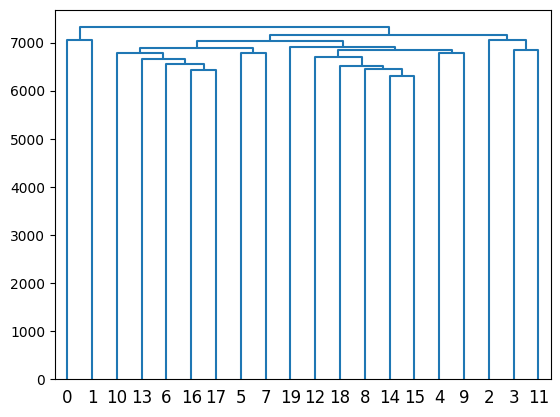

In [20]:
dendrogram(Z, labels=np.arange(nseg))
plt.show()

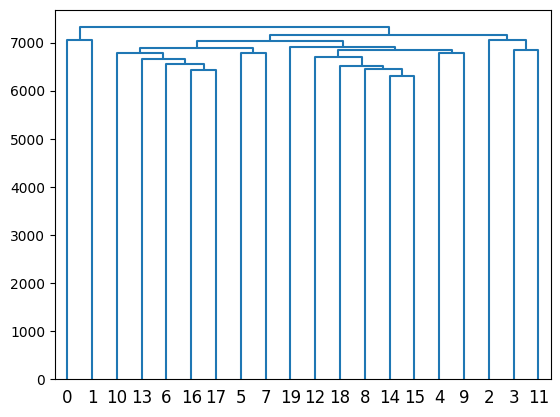

In [ ]:
dendrogram(Z, labels=np.arange(nseg))
plt.show()

In [ ]:
Dr = D[np.ix_(idx, idx)]
Dsqf = squareform(Dr)
Z = linkage(Dsqf, method="complete")

In [14]:
idx

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

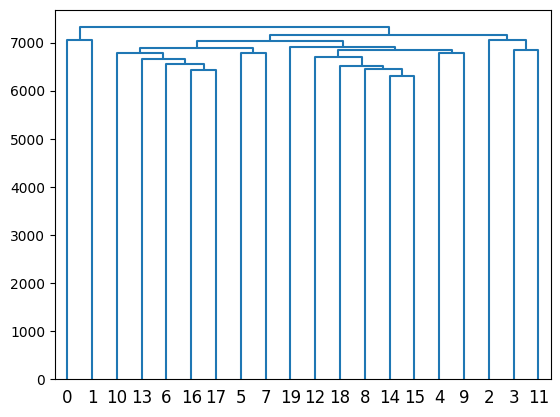

In [13]:
dendrogram(Z, labels=np.arange(nseg))
plt.show()

In [5]:
results

[([7262.920086679005,
   6875.460971751445,
   6786.074330886987,
   7019.460101976783,
   6933.572222012831,
   7502.84831770593,
   6961.302068784573,
   6462.613934625561,
   6756.3478750123395,
   6907.482173718216,
   6778.020624156627,
   6819.269275894817,
   7302.442531088446,
   7054.600318270961,
   7203.604596271383,
   6901.407010772727,
   7447.409682744713,
   6838.6841548875855,
   7323.933199205486,
   6962.005257766768,
   6983.776769055704,
   7222.775044204046,
   7200.372503915835,
   7337.955834362329,
   7448.225666326573,
   7043.7583184407595,
   6912.429184384742,
   7068.12515297592,
   7612.775533549329,
   7061.253852861207,
   7577.346527118458,
   7246.848061640822,
   6814.511076431078,
   7148.494595898074,
   6838.629140894563,
   6705.663095384891,
   6854.417089353006,
   7515.440339231225,
   7489.394979320047,
   6741.290040951065,
   6994.044394077357,
   7180.11842857361,
   6874.5606385542205,
   7094.2004876798665,
   6996.751943214823,
   7040.

In [4]:
indices

[(0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 9),
 (0, 10),
 (0, 11),
 (0, 12),
 (0, 13),
 (0, 14),
 (0, 15),
 (0, 16),
 (0, 17),
 (0, 18),
 (0, 19),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (1, 10),
 (1, 11),
 (1, 12),
 (1, 13),
 (1, 14),
 (1, 15),
 (1, 16),
 (1, 17),
 (1, 18),
 (1, 19),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (2, 7),
 (2, 8),
 (2, 9),
 (2, 10),
 (2, 11),
 (2, 12),
 (2, 13),
 (2, 14),
 (2, 15),
 (2, 16),
 (2, 17),
 (2, 18),
 (2, 19),
 (3, 4),
 (3, 5),
 (3, 6),
 (3, 7),
 (3, 8),
 (3, 9),
 (3, 10),
 (3, 11),
 (3, 12),
 (3, 13),
 (3, 14),
 (3, 15),
 (3, 16),
 (3, 17),
 (3, 18),
 (3, 19),
 (4, 5),
 (4, 6),
 (4, 7),
 (4, 8),
 (4, 9),
 (4, 10),
 (4, 11),
 (4, 12),
 (4, 13),
 (4, 14),
 (4, 15),
 (4, 16),
 (4, 17),
 (4, 18),
 (4, 19),
 (5, 6),
 (5, 7),
 (5, 8),
 (5, 9),
 (5, 10),
 (5, 11),
 (5, 12),
 (5, 13),
 (5, 14),
 (5, 15),
 (5, 16),
 (5, 17),
 (5, 18),
 (5, 19),
 (6, 7),
 (6, 8),
 (6, 9),
 (6, 10),
 (6, 11),
 (

In [3]:
# 0,2022-06-05T11:12:32.620000Z,2022-06-05T12:26:42.620000Z,2022-06-05T11:22:32.620000Z,2022-06-05T11:19:12.620000Z,2022-06-05T11:49:12.620000Z,0.7915276117050521

In [9]:
st

1 Trace(s) in Stream:
XP.ILL12..EHZ | 2022-06-05T11:12:32.620000Z - 2022-06-05T12:26:42.620000Z | 100.0 Hz, 445001 samples

In [3]:
if_mod = load(f"../output/TE/if/models/ILL12.joblib")

In [5]:
paths = find_paths("XP", "ILL12", "EHZ.D", start=2018, stop=2022)

In [13]:
st = obspy.read(find_date_in_strings(paths, "2022-06-05")[0])
preproc_stream(st)
st.trim(
    obspy.UTCDateTime("2022-06-05T11:12:32.620000Z"),
    obspy.UTCDateTime("2022-06-05T12:26:42.620000Z") - timedelta(seconds=0.01),
)
# t0 = obspy.UTCDateTime("2019-06-13T04:09:37.370000Z")
# t1 = obspy.UTCDateTime("2019-06-13T04:09:37.370000Z") + timedelta(seconds=99.99)
# x1 = st.trim(t0, t1)[0].data.reshape(1, -1)

1 Trace(s) in Stream:
XP.ILL12..EHZ | 2022-06-05T11:12:32.620000Z - 2022-06-05T12:26:42.610000Z | 100.0 Hz, 445000 samples

In [18]:
st[0]

XP.ILL12..EHZ | 2022-06-05T11:12:32.620000Z - 2022-06-05T12:26:42.610000Z | 100.0 Hz, 445000 samples

In [15]:
signal = st[0].data
window = 10000
overlap = 5000
step = window - overlap

starts = np.arange(0, len(signal) - window + 1, step)

X = np.stack([signal[s : s + window] for s in starts])

In [22]:
sc = -if_mod.score_samples(X)

In [24]:
np.argmax(sc)

12

In [77]:
len(sc)

88

In [161]:
obspy.UTCDateTime("2022-06-05T11:12:32.620000Z") + timedelta(seconds=low * 50)

2022-06-05T11:19:12.620000Z

In [162]:
obspy.UTCDateTime("2022-06-05T11:12:32.620000Z") + timedelta(seconds=high * 50)

2022-06-05T11:49:12.620000Z

In [157]:
low = 8
high = 44

In [158]:
sc[low - 1]

0.7185121291887379

In [159]:
sc[high + 1]

0.7492542298796484

In [160]:
timedelta(seconds=high * 50) - timedelta(seconds=low * 50)

datetime.timedelta(seconds=1800)

In [131]:
30 * 60 / 50

36.0

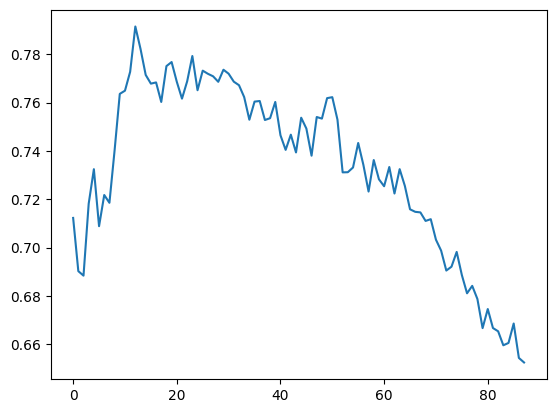

In [76]:
plt.plot(sc)

In [19]:
np.argmax(-if_mod.score_samples(X))

12

In [21]:
12 * 50 / 60

10.0

In [14]:
st[0].data.shape

(445000,)

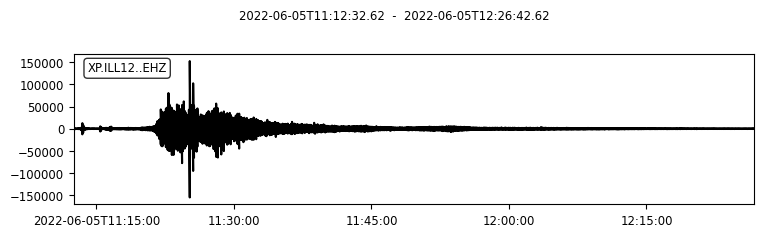

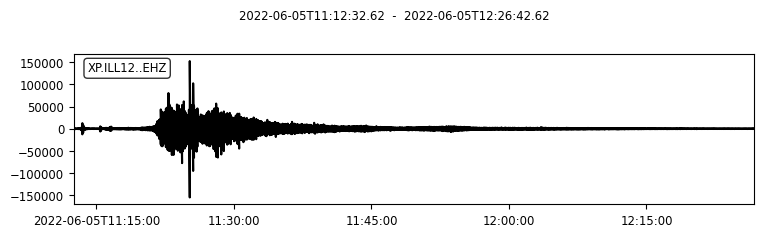

In [11]:
st.plot()

In [376]:
X1 = np.random.rand(100, 5)  # 100 samples, 5 features
X2 = np.random.rand(10, 5)  # 100 samples, 5 features
model = IsolationForest(warm_start=True, n_estimators=0, random_state=42)

array([-0.26066026, -0.28126994, -0.30261082, -0.25002505, -0.34144787,
       -0.27106069, -0.41684105, -0.30017384, -0.39543223, -0.35654353,
       -0.36892122, -0.30974869, -0.25640853, -0.2771574 , -0.39197192,
       -0.30284731, -0.38296944, -0.34188493, -0.29804757, -0.39674075,
       -0.25763376, -0.38564321, -0.26967234, -0.26948302, -0.41281714,
       -0.39522233, -0.30863088, -0.34306116, -0.24816589, -0.37389692,
       -0.31195745, -0.39889854, -0.29651228, -0.27955246, -0.26644775,
       -0.27826892, -0.28787581, -0.27161597, -0.29011112, -0.302109  ,
       -0.32426147, -0.39046364, -0.30582746, -0.29063131, -0.2787475 ,
       -0.28769628, -0.25783085, -0.27730355, -0.29698395, -0.25190492,
       -0.25292224, -0.37533341, -0.32925782, -0.37737477, -0.30286566,
       -0.31738527, -0.42164994, -0.34877902, -0.32142395, -0.39783043,
       -0.33319548, -0.31940432, -0.32977041, -0.32698051, -0.28303685,
       -0.25507079, -0.32940791, -0.28745666, -0.24838594, -0.38

In [403]:
import numpy as np


def compute_c(n):
    """
    Compute the average path length of an unsuccessful search in a binary search tree.
    n can be an integer or a NumPy array.
    """
    gamma = 0.5772156649
    n = np.array(n)
    c = np.zeros_like(n, dtype=float)
    mask = n > 1
    c[mask] = 2 * (np.log(n[mask] - 1) + gamma) - 2 * (n[mask] - 1) / n[mask]
    return c


def reweighted_score_samples(model, X):
    """
    Compute Isolation Forest anomaly scores manually, reproducing model.score_samples.

    Parameters:
        model: trained sklearn IsolationForest
        X: array-like of shape (n_samples, n_features)

    Returns:
        scores: array of anomaly scores for each sample
    """
    scores = []

    for tree in model.estimators_:
        node_counts = tree.decision_path(X).toarray().sum(axis=1)
        leaf_nodes = tree.apply(X)
        n_leaf = tree.tree_.n_node_samples[leaf_nodes]
        edges = node_counts - 1

        h = edges + compute_c(n_leaf)
        scores.append(h / compute_c(tree.tree_.n_node_samples[0]))

    scores = np.array(scores).T
    return 2 ** (-scores.mean(axis=1))

In [404]:
model.n_estimators += 1
model.fit(X1)
model.n_estimators += 1
model.fit(X2)
model.score_samples(X1)

array([-0.29323617, -0.2830453 , -0.31061818, -0.27440845, -0.35317185,
       -0.2791875 , -0.35846332, -0.31924705, -0.36435885, -0.33524618,
       -0.33132439, -0.31147043, -0.25736764, -0.31280224, -0.3872802 ,
       -0.32259328, -0.36610055, -0.35631209, -0.3389665 , -0.44419964,
       -0.29825522, -0.36194317, -0.28221944, -0.28116006, -0.38500681,
       -0.36052898, -0.29447083, -0.35431435, -0.25815961, -0.36388836,
       -0.35680993, -0.33380521, -0.29999917, -0.2985628 , -0.29079968,
       -0.30154232, -0.2959966 , -0.32074812, -0.30084332, -0.32373677,
       -0.34202797, -0.39374506, -0.35461496, -0.30719216, -0.29450726,
       -0.32264891, -0.26876787, -0.28990726, -0.33706005, -0.28538968,
       -0.2668119 , -0.36339379, -0.33376642, -0.38504121, -0.31607094,
       -0.32086815, -0.40533339, -0.3517722 , -0.34387614, -0.37984129,
       -0.33118916, -0.33917608, -0.34209645, -0.30790883, -0.30270637,
       -0.27452175, -0.34746551, -0.29462319, -0.28696348, -0.39

In [405]:
reweighted_score_samples(model, X1)

array([0.49608003, 0.48957389, 0.50949579, 0.48097736, 0.54534833,
       0.48155585, 0.56544139, 0.51255056, 0.56167893, 0.53276433,
       0.52684354, 0.5012358 , 0.46666472, 0.50012364, 0.5777544 ,
       0.5155913 , 0.56118482, 0.54442157, 0.54426166, 0.61950762,
       0.49350433, 0.55202605, 0.48402238, 0.48102461, 0.58280155,
       0.54535983, 0.50374693, 0.56199269, 0.46261419, 0.55521557,
       0.52700789, 0.52200051, 0.49745874, 0.50687229, 0.49160287,
       0.50232929, 0.49981064, 0.50634293, 0.50121752, 0.52217139,
       0.53022877, 0.59130472, 0.56171442, 0.50093676, 0.4919027 ,
       0.51654748, 0.46820533, 0.49799063, 0.54907706, 0.48370216,
       0.46891722, 0.5658916 , 0.53076588, 0.56118514, 0.52090869,
       0.52350703, 0.57680002, 0.54401984, 0.52785083, 0.54769056,
       0.53910077, 0.51872589, 0.52226184, 0.51283612, 0.50305013,
       0.47932931, 0.53962438, 0.48904514, 0.49659888, 0.56875135,
       0.52083884, 0.45806414, 0.50373693, 0.59930784, 0.46761

In [394]:
model.score_samples(X1)

array([-0.24695803, -0.27045165, -0.26385593, -0.24331437, -0.31401772,
       -0.25809591, -0.41238139, -0.30790158, -0.3686391 , -0.33921626,
       -0.38828653, -0.2911623 , -0.26913236, -0.29662547, -0.35628101,
       -0.29871705, -0.3871478 , -0.35978106, -0.2896116 , -0.38767651,
       -0.25381285, -0.36562068, -0.26930311, -0.25816337, -0.39810331,
       -0.40407546, -0.31658299, -0.30865673, -0.24840526, -0.37700793,
       -0.29375989, -0.37268282, -0.32274067, -0.27974833, -0.28236795,
       -0.27425076, -0.26569279, -0.28262277, -0.27360695, -0.29556468,
       -0.32179416, -0.3628583 , -0.33546402, -0.28373203, -0.27896349,
       -0.29198711, -0.24361175, -0.27190494, -0.32338254, -0.26323653,
       -0.26031805, -0.37881935, -0.34324837, -0.3813965 , -0.28309737,
       -0.30865673, -0.41833675, -0.31510061, -0.32179416, -0.38012036,
       -0.30455975, -0.31578025, -0.32864239, -0.32036468, -0.26620387,
       -0.23933786, -0.32819088, -0.27680533, -0.24132211, -0.37

In [8]:
np.all(np.array([tree.tree_.n_node_samples[0] for tree in if_mod.estimators_]) == 256)

True

In [ ]:
for tree in if_mod.estimators_:
    print()

256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256


In [3]:
paths = find_paths("XP", "ILL18", "EHZ.D", start=2018, stop=2019)
if_mod = load(f"../output/XP/if/models/ILL18.joblib")

st = obspy.read(find_date_in_strings(paths, "2019-06-13")[0])
preproc_stream(st)
t0 = obspy.UTCDateTime("2019-06-13T04:09:37.370000Z")
t1 = obspy.UTCDateTime("2019-06-13T04:09:37.370000Z") + timedelta(seconds=99.99)
x1 = st.trim(t0, t1)[0].data.reshape(1, -1)


st = obspy.read(find_date_in_strings(paths, "2019-06-20")[0])
preproc_stream(st)
t0 = obspy.UTCDateTime("2019-06-20T09:09:37.370000Z")
t1 = obspy.UTCDateTime("2019-06-20T09:09:37.370000Z") + timedelta(seconds=99.99)
x2 = st.trim(t0, t1)[0].data.reshape(1, -1)

st = obspy.read(find_date_in_strings(paths, "2018-06-11")[0])
preproc_stream(st)
t0 = obspy.UTCDateTime("2018-06-11T11:00:03.740003Z")
t1 = obspy.UTCDateTime("2018-06-11T11:00:03.740003Z") + timedelta(seconds=99.99)
x3 = st.trim(t0, t1)[0].data.reshape(1, -1)

In [111]:
obspy.read("../data/XP/2018/ILL18/EHZ.D/XP.ILL18..EHZ.D.2018.147")

1 Trace(s) in Stream:
XP.ILL18..EHZ | 2018-05-27T00:00:03.000000Z - 2018-05-28T00:00:03.950000Z | 100.0 Hz, 8640096 samples

In [5]:
est = if_mod.estimators_[5]
tree = est.tree_

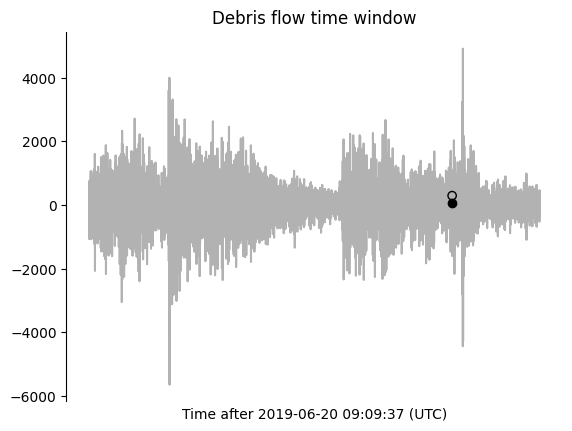

In [117]:
plt.plot(x2[0, :], c="k", alpha=0.3)

plt.scatter(tree.feature[0], tree.threshold[0], color="k", zorder=3, marker="o")
plt.scatter(
    tree.feature[0],
    x2[0, tree.feature[0]],
    color="k",
    zorder=3,
    marker="o",
    facecolors="none",
)


ax = plt.gca()

ax.spines["bottom"].set_visible(False)
ax.xaxis.set_ticks([])

ax.spines["left"].set_visible(True)
ax.yaxis.set_ticks_position("left")
ax.yaxis.set_tick_params(labelleft=True)  # show amplitude numbers

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("Debris flow time window")
ax.set_xlabel("Time after 2019-06-20 09:09:37 (UTC)")

plt.savefig("../plots/tree_flow_example1.pdf", dpi=300)

plt.show()

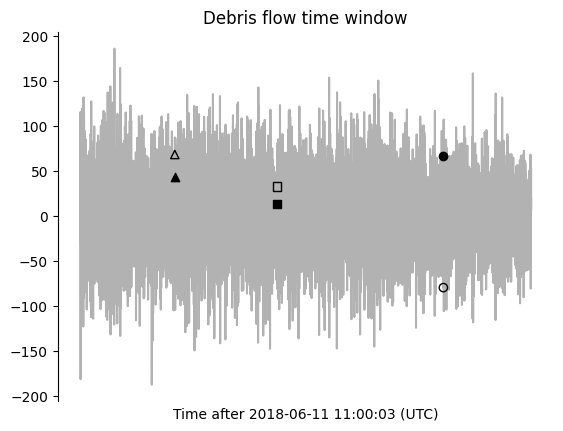

In [118]:
plt.plot(x3[0, :], c="k", alpha=0.3)

# split markers
plt.scatter(tree.feature[0], tree.threshold[0], color="k", zorder=3)
plt.scatter(
    tree.feature[0],
    x3[0, tree.feature[0]],
    color="k",
    zorder=3,
    marker="o",
    facecolors="none",
)
plt.scatter(tree.feature[1], tree.threshold[1], color="k", marker="s", zorder=3)
plt.scatter(
    tree.feature[1],
    x3[0, tree.feature[1]],
    color="k",
    zorder=3,
    marker="s",
    facecolors="none",
)
plt.scatter(tree.feature[41], tree.threshold[41], color="k", marker="^", zorder=3)
plt.scatter(
    tree.feature[41],
    x3[0, tree.feature[41]],
    color="k",
    zorder=3,
    marker="^",
    facecolors="none",
)

ax = plt.gca()

# Hide x-axis completely
ax.spines["bottom"].set_visible(False)
ax.xaxis.set_ticks([])  # remove x ticks

# Keep left y-axis with tick marks and labels
ax.spines["left"].set_visible(True)
ax.yaxis.set_ticks_position("left")
ax.yaxis.set_tick_params(labelleft=True)  # show amplitude numbers

ax.set_title("Debris flow time window")
ax.set_xlabel("Time after 2018-06-11 11:00:03 (UTC)")

# Hide top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.savefig("../plots/tree_flow_example2.pdf", dpi=300)
plt.show()

In [56]:
for j in nodes1:
    print(f"Node {j}: feature {tree.feature[j]}, threshold {tree.threshold[j]}")

Node 0: feature 8052, threshold 67.26235521439678
Node 1: feature 4361, threshold 13.417043675448596
Node 2: feature 3927, threshold 16.493940701483496
Node 3: feature 3812, threshold 7.406475184246428
Node 4: feature 5771, threshold 15.683214243884166
Node 5: feature 2625, threshold -7.754937334951332
Node 11: feature 7941, threshold 15.79976151581959
Node 12: feature 8073, threshold -9.519989097054708
Node 14: feature -2, threshold -2.0


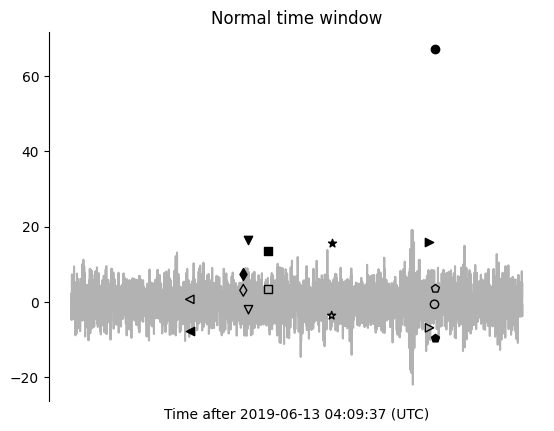

In [120]:
plt.plot(x1[0, :], c="k", alpha=0.3)

# split markers
plt.scatter(tree.feature[0], tree.threshold[0], color="k", zorder=3)
plt.scatter(
    tree.feature[0],
    x1[0, tree.feature[0]] - 2,
    color="k",
    zorder=3,
    marker="o",
    facecolors="none",
)
plt.scatter(tree.feature[1], tree.threshold[1], color="k", marker="s", zorder=3)
plt.scatter(
    tree.feature[1],
    x1[0, tree.feature[1]],
    color="k",
    zorder=3,
    marker="s",
    facecolors="none",
)
plt.scatter(tree.feature[2], tree.threshold[2], color="k", marker="v", zorder=3)
plt.scatter(
    tree.feature[2],
    x1[0, tree.feature[2]],
    color="k",
    zorder=3,
    marker="v",
    facecolors="none",
)
plt.scatter(tree.feature[3], tree.threshold[3], color="k", marker="d", zorder=3)
plt.scatter(
    tree.feature[3],
    x1[0, tree.feature[3]],
    color="k",
    zorder=3,
    marker="d",
    facecolors="none",
)
plt.scatter(tree.feature[4], tree.threshold[4], color="k", marker="*", zorder=3)
plt.scatter(
    tree.feature[4],
    x1[0, tree.feature[4]],
    color="k",
    zorder=3,
    marker="*",
    facecolors="none",
)
plt.scatter(tree.feature[5], tree.threshold[5], color="k", marker="<", zorder=3)
plt.scatter(
    tree.feature[5],
    x1[0, tree.feature[5]],
    color="k",
    zorder=3,
    marker="<",
    facecolors="none",
)
plt.scatter(tree.feature[11], tree.threshold[11], color="k", marker=">", zorder=3)
plt.scatter(
    tree.feature[11],
    x1[0, tree.feature[11]],
    color="k",
    zorder=3,
    marker=">",
    facecolors="none",
)
plt.scatter(tree.feature[12], tree.threshold[12], color="k", marker="p", zorder=3)
plt.scatter(
    tree.feature[12],
    x1[0, tree.feature[12]] + 2,
    color="k",
    zorder=3,
    marker="p",
    facecolors="none",
)


ax = plt.gca()

# Hide x-axis completely
ax.spines["bottom"].set_visible(False)
ax.xaxis.set_ticks([])  # remove x ticks

# Keep left y-axis with tick marks and labels
ax.spines["left"].set_visible(True)
ax.yaxis.set_ticks_position("left")
ax.yaxis.set_tick_params(labelleft=True)  # show amplitude numbers
ax.set_title("Normal time window")
ax.set_xlabel("Time after 2019-06-13 04:09:37 (UTC)")
# Hide top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.savefig("../plots/tree_flow_example3.pdf", dpi=300)
plt.show()

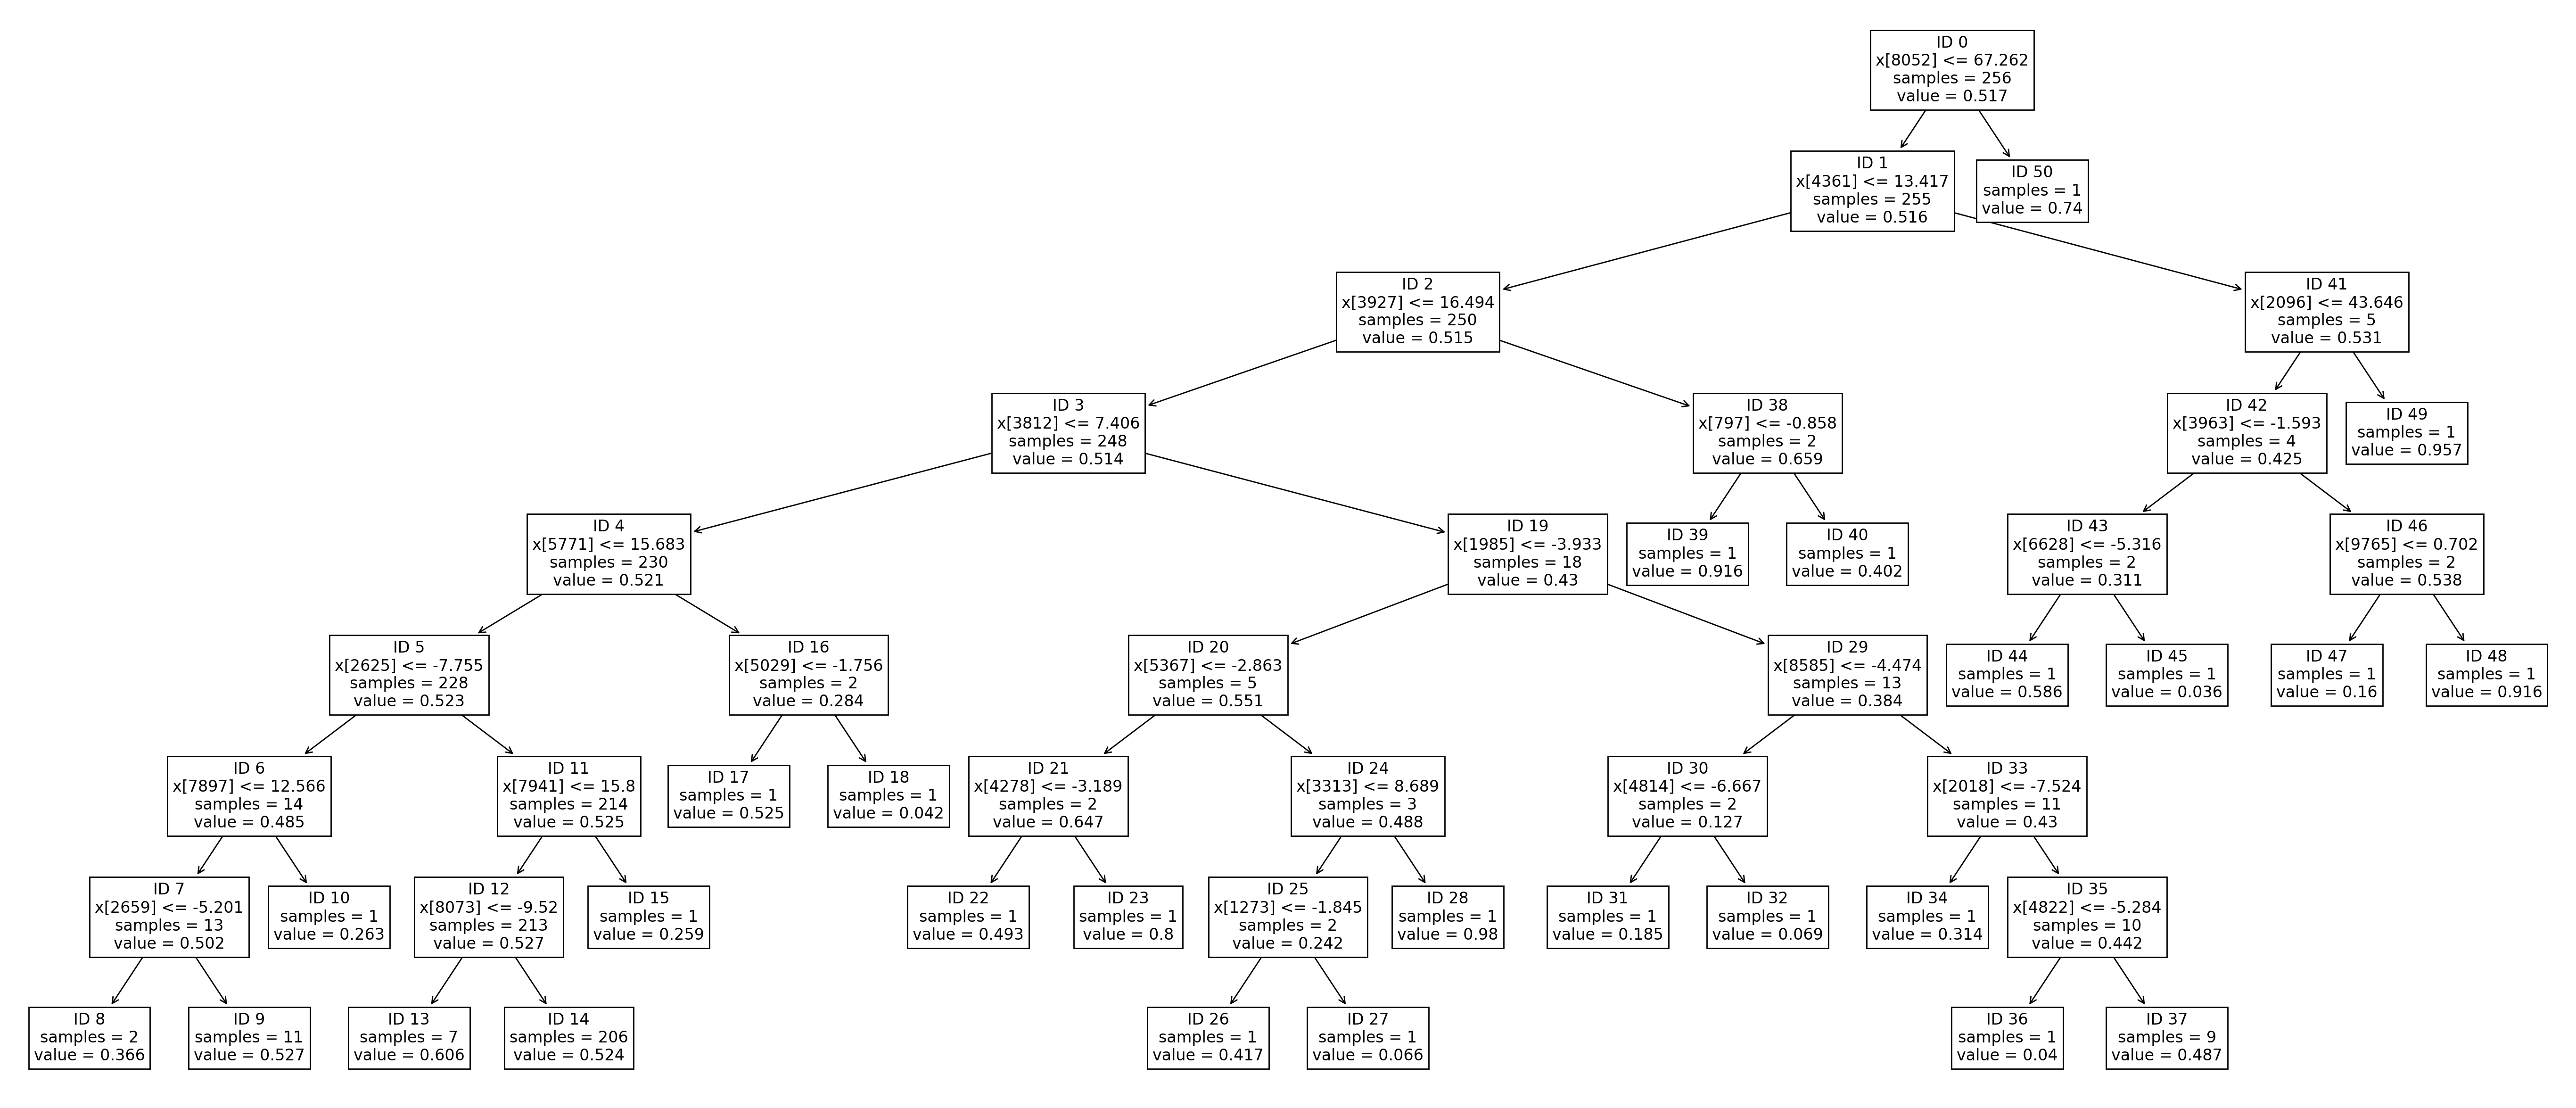

In [104]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(35, 15), dpi=200)
ax = plt.gca()

# plot the tree and capture the Text objects
texts = plot_tree(
    est,
    max_depth=10,
    filled=False,
    impurity=False,
    proportion=False,
    fontsize=12,
    ax=ax,
)

# Add node indices manually
for i, txt_obj in enumerate(texts):
    # txt_obj is a matplotlib.text.Text object for the node label
    current_label = txt_obj.get_text()
    txt_obj.set_text(f"ID {i}\n{current_label}")  # prepend node index

plt.show()

### Rock Avalanche

In [157]:
nuug_paths = find_paths("DK", "NUUG", "HHZ.D", start=2017, stop=2017)
ra_paths = [
    find_date_in_strings(nuug_paths, "2017-06-17")[0],
    find_date_in_strings(nuug_paths, "2017-06-18")[0],
]

scores_df = pd.read_csv(f"../output/DK/if/scores/NUUG.csv", index_col=0)
scores_df["start"] = [obspy.UTCDateTime(str(i)) for i in scores_df["start"]]
scores_df["stop"] = [obspy.UTCDateTime(str(i)) for i in scores_df["stop"]]

if_st = create_if_stream(scores_df, station="NUUG", sr=0.02, network="DK")


ra_tr = obspy.Trace()
st1 = obspy.read(ra_paths[0])
preproc_stream(st1)
st2 = obspy.read(ra_paths[1])
preproc_stream(st2)
st2.trim(
    starttime=st[0].stats.starttime + timedelta(seconds=0.01),
    endtime=st[0].stats.endtime,
)
ra_tr.data = np.concatenate((st1[0].data, st2[0].data))
ra_tr.stats.starttime = st1[0].stats.starttime
ra_tr.stats.sampling_rate = st1[0].stats.sampling_rate

t0 = obspy.UTCDateTime("2017-06-17T23:30:00.000000Z")
t1 = obspy.UTCDateTime("2017-06-18T00:30:00.000000Z")

ra_tr.trim(t0, t1)
if_tr = if_st.copy().trim(t0, t1)[0]

trigger_on = obspy.UTCDateTime("2017-06-17T23:39:11.680001Z") - t0
trigger_off = obspy.UTCDateTime("2017-06-18T00:17:31.680001Z") - t0

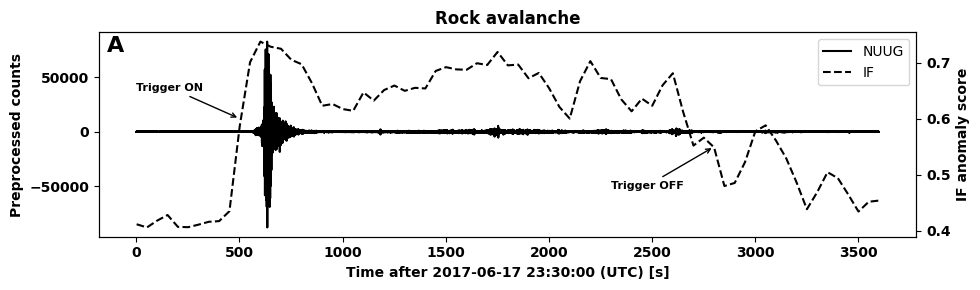

In [172]:
# waveform
npts1 = ra_tr.stats.npts
dt1 = 1 / ra_tr.stats.sampling_rate
start_offset = ra_tr.stats.starttime - t0
t1 = np.arange(0, npts1) * dt1 + +start_offset

npts2 = if_tr.stats.npts
dt2 = 1 / if_tr.stats.sampling_rate
start_offset = if_tr.stats.starttime - t0
t2 = np.arange(0, npts2) * dt2 + start_offset

fig, ax1 = plt.subplots(figsize=(10, 3))
ax1.plot(t1, tr1.data, color="black", label="NUUG")
ax1.set_xlabel(
    f"Time after {t0.strftime('%Y-%m-%d %H:%M:%S')} (UTC) [s]", fontweight="bold"
)
ax1.set_ylabel("Preprocessed counts", color="black", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="black")

ax2 = ax1.twinx()
ax2.plot(t2, if_tr.data, color="black", label="IF", linestyle="--")
ax2.set_ylabel("IF anomaly score", color="black", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="black")

ax1.set_ylabel("Preprocessed counts")

for label in ax1.get_xticklabels() + ax1.get_yticklabels() + ax2.get_yticklabels():
    label.set_fontweight("bold")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()


ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")
ax1.text(
    0.01,
    0.98,
    "A",
    transform=ax1.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
    ha="left",
)


plt.annotate(
    "Trigger ON",
    xy=(trigger_on - 50, 0.6),
    xytext=(0, 0.65),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=8,
    fontweight="bold",
)

plt.annotate(
    "Trigger OFF",
    xy=(trigger_off - 50, 0.55),
    xytext=(2300, 0.475),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=8,
    fontweight="bold",
)

plt.title("Rock avalanche", fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/fig02.pdf", dpi=300)
plt.show()

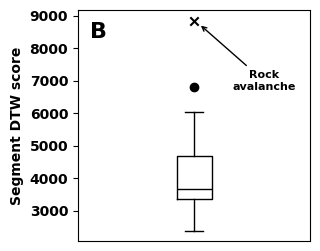

In [219]:
# dendrogram boxplot
with open(f"../output/DK/dtw/info/NUUG.pkl", "rb") as f:
    info = pickle.load(f)

indices = info[0]
d = np.array([np.median(i[0]) for i in info[1]])

D = np.zeros([50, 50])

for n in range(len(indices)):
    i, j = indices[n]

    D[i, j] = d[n]

D = D + D.T

condensed_D = squareform(D)
linkage_matrix = sch.linkage(condensed_D, method="complete")

hh = []

for i in range(linkage_matrix.shape[0]):
    if linkage_matrix[i, 0] < 50 or linkage_matrix[i, 1] < 50:
        hh.append(linkage_matrix[i, 2])

hh = np.array(hh)

fig, ax = plt.subplots(figsize=(3, 3))
box = ax.boxplot(hh, patch_artist=False, flierprops=dict(marker=""))

IQR = np.quantile(hh, 0.75) - np.quantile(hh, 0.25)
up = np.quantile(hh, 0.75) + 1.5 * IQR

outliers = np.sort(hh[hh > up])

for i in range(outliers.shape[0] - 1):
    plt.scatter(1, outliers[i], c="k", marker="o")

plt.scatter(1, outliers[-1], c="k", marker="x")

ax.text(
    0.05,
    0.95,
    "B",
    transform=ax.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
    ha="left",
)

ax.set_xticks([])
ax.set_xticklabels([])
ax.tick_params(axis="x", bottom=False)

for element in ["boxes", "whiskers", "caps", "medians"]:
    plt.setp(box[element], color="black")

plt.ylabel("Segment DTW score", fontweight="bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

plt.annotate(
    "Rock\navalanche",
    xy=(1.02, outliers[-1] - 100),
    xytext=(1.3, 7000),
    ha="center",
    va="center",
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=8,
    fontweight="bold",
)

# plt.tight_layout()
plt.savefig(
    "../plots/fig03.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
    pad_inches=0.1,
)
plt.show()

### KARAT Dendrogram

In [226]:
with open(f"../output/DK/dtw/info/KARAT.pkl", "rb") as f:
    info = pickle.load(f)

karat_dtc = pd.read_csv("../catalogs/DK/KARAT.csv")

indices = info[0]
d = np.array([np.median(i[0]) for i in info[1]])

D = np.zeros([50, 50])

for n in range(len(indices)):
    i, j = indices[n]

    D[i, j] = d[n]

D = D + D.T

condensed_D = squareform(D)
linkage_matrix = sch.linkage(condensed_D, method="complete")

In [273]:
from matplotlib.lines import Line2D

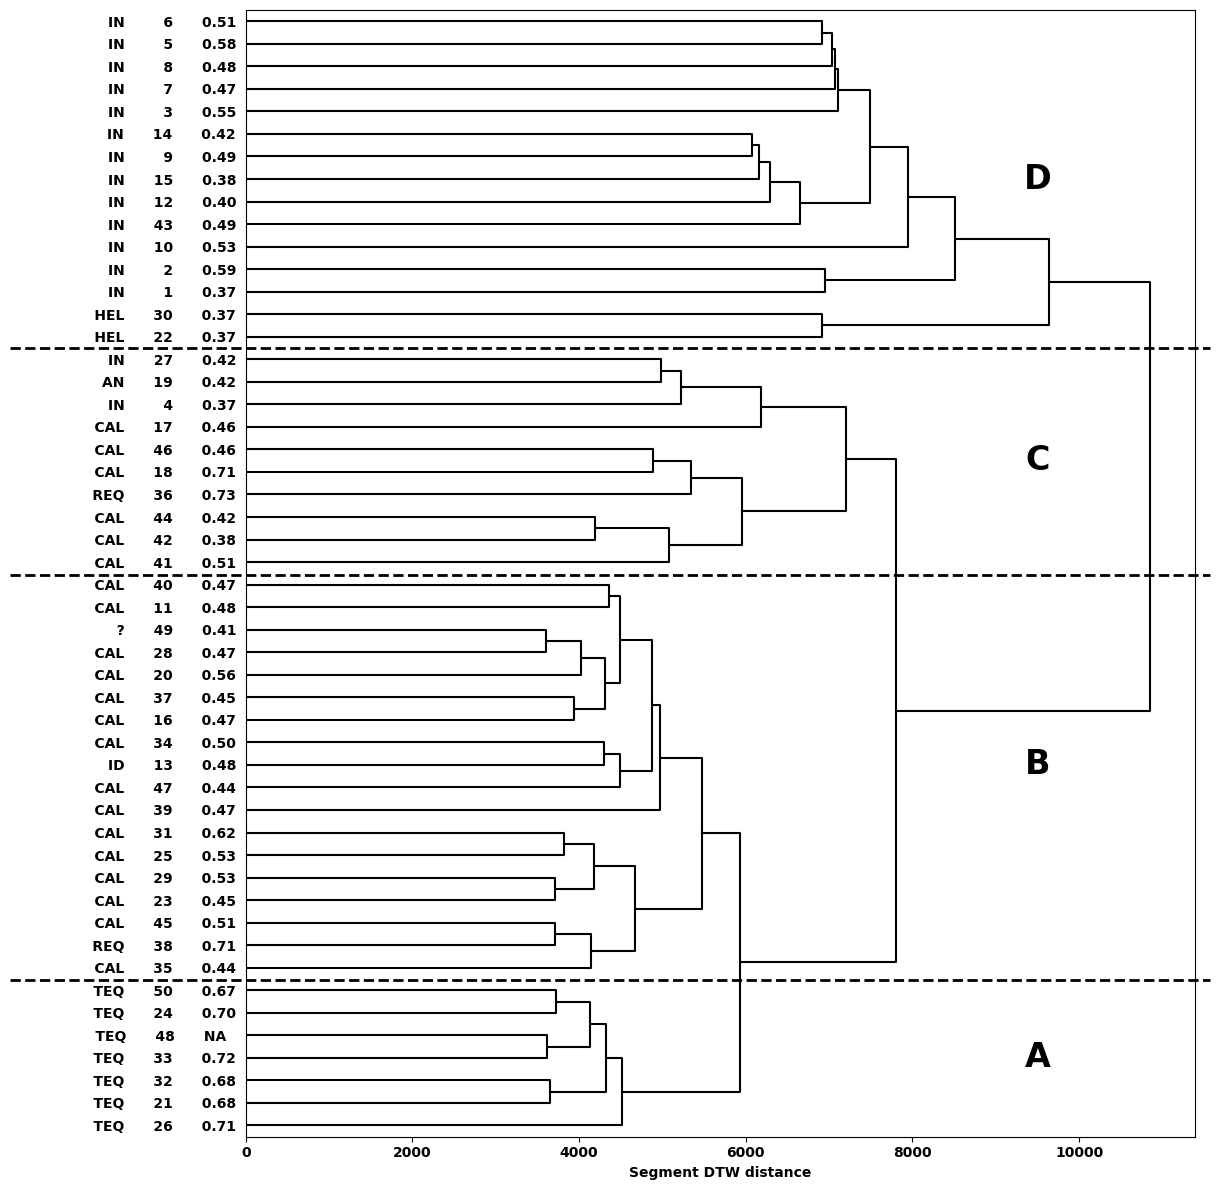

In [305]:
value_width = 6
name_width = 10
index_width = 4
spacer = "\u2007"

labels = []
for i in range(karat_dtc.shape[0]):
    name = str(karat_dtc["labels"][i]).rjust(name_width)
    index = str(i + 1).rjust(index_width)

    value = karat_dtc.iloc[i, 3]
    if pd.isna(value):
        value_str = " NA ".rjust(value_width - 1)
    else:
        value_str = f"{value:.2f}".rjust(value_width)

    name = name.replace(" ", spacer)
    index = index.replace(" ", spacer)
    value_str = value_str.replace(" ", spacer)

    label = f"{name}  {index}  {value_str}"
    labels.append(label)

fig = plt.figure(figsize=(12, 12))
dendro = sch.dendrogram(
    linkage_matrix,
    labels=labels,
    orientation="right",
    link_color_func=lambda k: "black",
)

for label in plt.gca().get_yticklabels():
    label.set_fontfamily("sans-serif")
    label.set_fontweight("bold")
    label.set_fontsize(10)

for label in plt.gca().get_xticklabels():
    label.set_fontweight("bold")

plt.xlabel("Segment DTW distance", fontweight="bold")
ymin, ymax = plt.gca().get_ylim()

plt.text(
    x=9500,
    y=425,
    s="D",
    horizontalalignment="center",
    verticalalignment="center",
    fontweight="bold",
    fontsize=24,
)
plt.text(
    x=9500,
    y=300,
    s="C",
    horizontalalignment="center",
    verticalalignment="center",
    fontweight="bold",
    fontsize=24,
)
plt.text(
    x=9500,
    y=165,
    s="B",
    horizontalalignment="center",
    verticalalignment="center",
    fontweight="bold",
    fontsize=24,
)
plt.text(
    x=9500,
    y=35,
    s="A",
    horizontalalignment="center",
    verticalalignment="center",
    fontweight="bold",
    fontsize=24,
)
# y_fig_coord = ax.transData.transform((0, 350))[1]

for y_fig_coord in [215, 620, 847.5]:
    y_fig_frac = y_fig_coord / fig.bbox.height

    # Draw line at that height in figure space
    line = Line2D(
        [0, 1],
        [y_fig_frac, y_fig_frac],
        transform=fig.transFigure,
        color="k",
        linestyle="--",
        linewidth=2,
    )
    fig.add_artist(line)

plt.tight_layout()
plt.savefig("../plots/fig04.pdf")
plt.show()

In [ ]:
# amplitude plot
karat_paths = find_paths("DK", "KARAT", "HHZ.D", start=2022, stop=2023)

In [ ]:
median_amplitudes = []
times = []

for p in karat_paths:
    st = obspy.read(p)
    preproc_stream(st)

    data = []

    for tr in st:
        data.append(tr.data)

    median_amplitudes.append(np.median(np.abs(np.concatenate(data))))

    year = st[0].stats.starttime.year
    month = st[0].stats.starttime.month
    day = st[0].stats.starttime.day
    times.append(pd.Timestamp(year=year, month=month, day=day))

    # print(times[-1],median_amplitudes[-1])

amplitide_df = pd.DataFrame({"times": times, "amplitudes": median_amplitudes})

scores_df = pd.read_csv(f"../output/DK/if/scores/KARAT.csv", index_col=0)
scores_df["start"] = [obspy.UTCDateTime(str(i)) for i in scores_df["start"]]
scores_df["stop"] = [obspy.UTCDateTime(str(i)) for i in scores_df["stop"]]
karat_if_st = create_if_stream(scores_df, station="KARAT", sr=0.02, network="DK")

2022-05-30 00:00:00 5275.997364103325
2022-05-31 00:00:00 1236.8649226567522
2022-06-03 00:00:00 3212.6555434864367
2022-06-11 00:00:00 411.02760469623456
2022-06-12 00:00:00 441.155804765071
2022-06-13 00:00:00 557.8480793681078
2022-06-14 00:00:00 449.2162233737763
2022-06-15 00:00:00 210.03355607945434
2022-06-16 00:00:00 181.1800942181004
2022-08-15 00:00:00 38.24685352928278
2022-08-16 00:00:00 32.81647866020248
2022-08-17 00:00:00 18.957138305390274
2022-08-18 00:00:00 15.906187338625715
2022-08-19 00:00:00 17.577020277494547
2022-08-20 00:00:00 17.046915782281395
2022-08-21 00:00:00 16.645113469339172
2022-08-22 00:00:00 52.70025436747578
2022-08-23 00:00:00 49.1640193157034
2022-08-24 00:00:00 53.33496148668124
2022-08-25 00:00:00 30.150985138043353
2022-08-26 00:00:00 26.35720054369049
2022-08-27 00:00:00 19.235133804913048
2022-08-28 00:00:00 17.575907773720672
2022-08-29 00:00:00 30.72902531663746
2022-08-30 00:00:00 47.67454161785585
2022-08-31 00:00:00 32.87833727253094
20

c:\Users\franc\anaconda3\envs\seismic-if-env\lib\site-packages\obspy\core\trace.py:1755: UserWarning: Resampled trace would have less than one sample. Retaining exactly one sample.
  warnings.warn(msg)


2022-09-17 00:00:00 31.462837239451908
2022-09-18 00:00:00 35.82678237101231
2022-09-19 00:00:00 27.03707236384334
2022-09-20 00:00:00 16.891480238404466
2022-09-21 00:00:00 19.256767630742935
2022-09-22 00:00:00 22.639288037046732
2022-09-23 00:00:00 26.64290516443097
2022-09-24 00:00:00 34.57162421034748
2022-09-25 00:00:00 66.79292290416453
2022-09-26 00:00:00 30.051380662725485
2022-09-27 00:00:00 19.288513510165004
2022-09-28 00:00:00 19.86105291073966
2022-09-29 00:00:00 31.015936284571755
2022-09-30 00:00:00 31.520900700130184
2022-10-01 00:00:00 40.67103837145769
2022-10-02 00:00:00 38.448353382951844
2022-10-03 00:00:00 29.543654241538007
2022-10-04 00:00:00 18.264370860660097
2022-10-05 00:00:00 27.018817441373955
2022-10-06 00:00:00 40.46010742732311
2022-10-07 00:00:00 37.57526580556781
2022-10-08 00:00:00 28.636470579973548
2022-10-09 00:00:00 31.315288765620352
2022-10-10 00:00:00 32.0597727296217
2022-10-11 00:00:00 28.256736224078413
2022-10-12 00:00:00 39.2931151340706

C:\Users\franc\AppData\Local\Temp\ipykernel_53756\2048165448.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


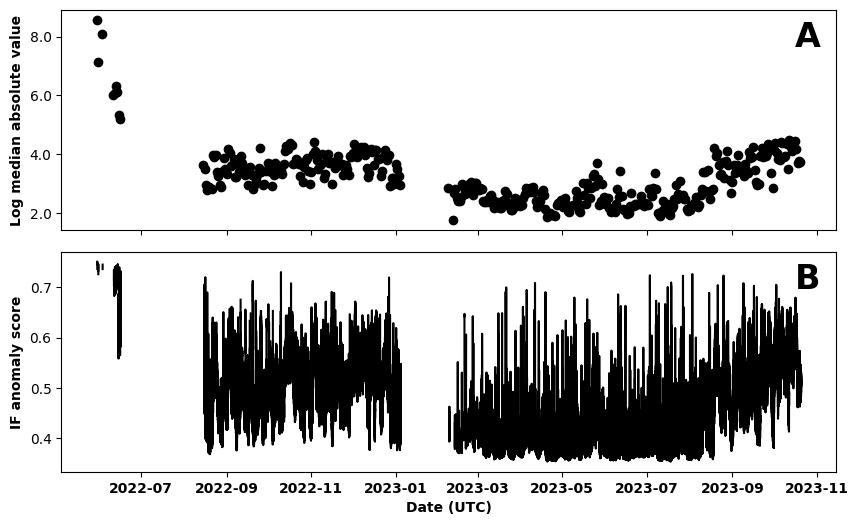

In [353]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(10, 6), gridspec_kw={"hspace": 0.1}
)

ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
ax1.scatter(amplitide_df["times"], np.log(amplitide_df["amplitudes"]), c="k")
ax1.set_ylabel("Log median absolute value", fontweight="bold")

ax1.text(
    0.98,
    0.95,
    "A",
    transform=ax1.transAxes,
    fontsize=24,
    fontweight="bold",
    va="top",
    ha="right",
)

for tr in karat_if_st:
    t = np.array(
        [tr.stats.starttime + i / tr.stats.sampling_rate for i in range(tr.stats.npts)]
    )
    t = np.array([ti.datetime for ti in t])
    ax2.plot(t, tr.data, color="black")

ax2.set_xlabel("Date (UTC)", fontweight="bold")
ax2.set_ylabel("IF anomaly score", fontweight="bold")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

for label in ax2.get_xticklabels():
    label.set_fontweight("bold")

ax2.text(
    0.98,
    0.95,
    "B",
    transform=ax2.transAxes,
    fontsize=24,
    fontweight="bold",
    va="top",
    ha="right",
)

fig.tight_layout()
plt.savefig("../plots/fig05.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

### Appendix A

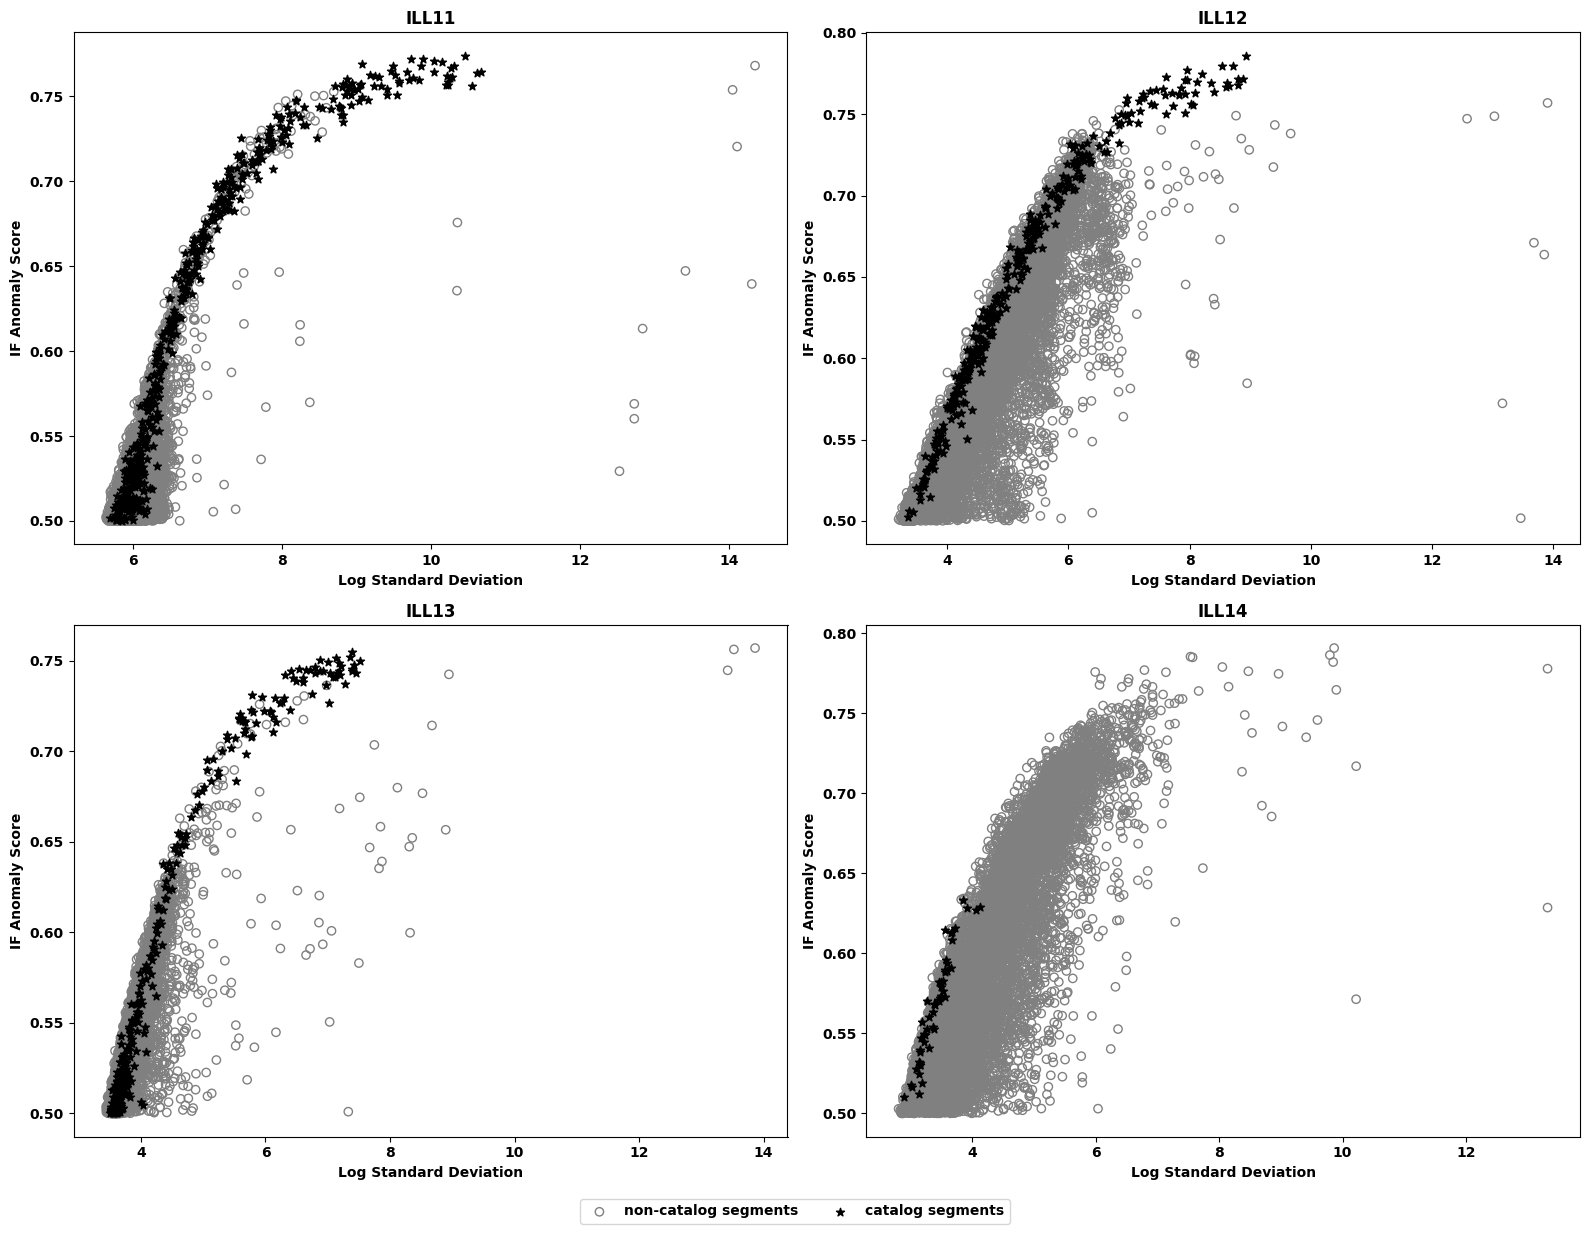

In [123]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

axs = axs.flatten()
h = 0

for station in ["ILL11", "ILL12", "ILL13", "ILL14"]:
    scores_df = pd.read_csv(f"../output/XP/if/scores/{station}.csv", index_col=0)
    scores_df = scores_df.iloc[
        : np.max(np.where(["2018" in i for i in scores_df["start"]])[0]), :
    ]
    scores_df["start"] = [obspy.UTCDateTime(i) for i in scores_df["start"]]
    scores_df["stop"] = [obspy.UTCDateTime(i) for i in scores_df["stop"]]
    flows = preproc_flow_annotations(
        pd.read_csv("../catalogs/XP/flow_catalog.csv", index_col=0)
    )
    _, _, station_flows = extract_split_flows(flows, station, 2018, 2018)
    high_conf = station_flows[station_flows["confidence"] == "high"].reset_index(
        drop=True
    )
    med_conf = station_flows[station_flows["confidence"] == "med"].reset_index(
        drop=True
    )
    low_conf = station_flows[station_flows["confidence"] == "low"].reset_index(
        drop=True
    )

    scores_df = scores_df[scores_df["anomaly_score"] > 0.5].reset_index(drop=True)
    psymb = np.zeros(scores_df.shape[0])

    for j in range(high_conf.shape[0]):
        t0_gt = high_conf["start"][j]
        t1_gt = high_conf["stop"][j]
        loc = np.where((scores_df["start"] >= t0_gt) & (scores_df["start"] <= t1_gt))[0]
        psymb[loc] = 1

    for j in range(med_conf.shape[0]):
        t0_gt = med_conf["start"][j]
        t1_gt = med_conf["stop"][j]
        loc = np.where((scores_df["start"] >= t0_gt) & (scores_df["start"] <= t1_gt))[0]
        psymb[loc] = 2

    for j in range(low_conf.shape[0]):
        t0_gt = low_conf["start"][j]
        t1_gt = low_conf["stop"][j]
        loc = np.where((scores_df["start"] >= t0_gt) & (scores_df["start"] <= t1_gt))[0]
        psymb[loc] = 3

    if h == 0:
        axs[h].scatter(
            np.log(scores_df["std"][psymb == 0]),
            scores_df["anomaly_score"][psymb == 0],
            marker="o",
            edgecolors="gray",
            facecolors="none",
            label="non-catalog segments",
        )
        axs[h].scatter(
            np.log(scores_df["std"][psymb != 0]),
            scores_df["anomaly_score"][psymb != 0],
            marker="*",
            color="black",
            label="catalog segments",
        )
    else:
        axs[h].scatter(
            np.log(scores_df["std"][psymb == 0]),
            scores_df["anomaly_score"][psymb == 0],
            marker="o",
            edgecolors="gray",
            facecolors="none",
        )
        axs[h].scatter(
            np.log(scores_df["std"][psymb != 0]),
            scores_df["anomaly_score"][psymb != 0],
            marker="*",
            color="black",
        )
    # axs[h].scatter(np.log(scores_df["std"][psymb == 2]), scores_df["anomaly_score"][psymb == 2],
    #                 marker="*", color="black")
    # axs[h].scatter(np.log(scores_df["std"][psymb == 3]), scores_df["anomaly_score"][psymb == 3],
    #                 marker="*", color="black")

    for label in axs[h].get_xticklabels():
        label.set_fontweight("bold")

    for label in axs[h].get_yticklabels():
        label.set_fontweight("bold")

    axs[h].set_title(station, fontweight="bold")
    axs[h].set_xlabel("Log Standard Deviation", fontweight="bold")
    axs[h].set_ylabel("IF Anomaly Score", fontweight="bold")

    h += 1

fig.legend(
    loc="lower center", bbox_to_anchor=(0.5, -0.03), ncol=2, prop={"weight": "bold"}
)
fig.tight_layout()
plt.savefig("../plots/fig06.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

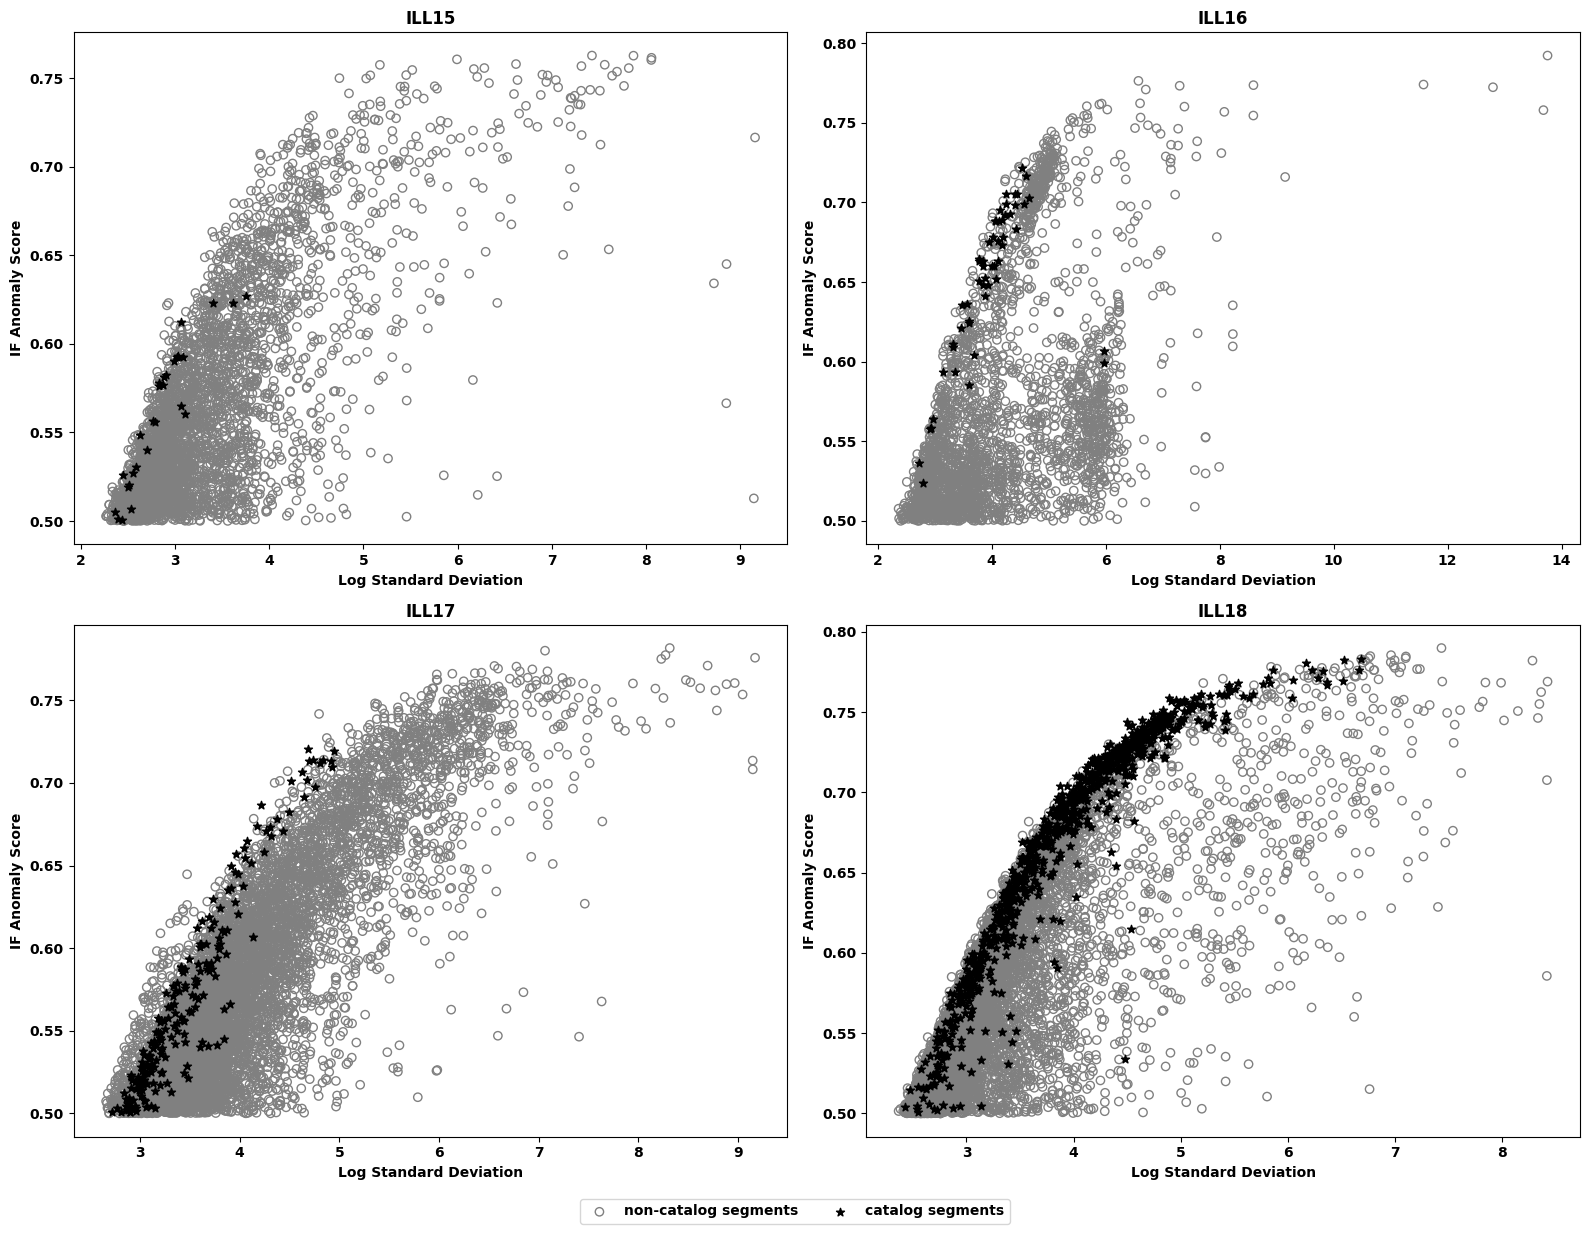

In [124]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

axs = axs.flatten()
h = 0

for station in ["ILL15", "ILL16", "ILL17", "ILL18"]:
    scores_df = pd.read_csv(f"../output/XP/if/scores/{station}.csv", index_col=0)
    scores_df = scores_df.iloc[
        : np.max(np.where(["2018" in i for i in scores_df["start"]])[0]), :
    ]
    scores_df["start"] = [obspy.UTCDateTime(i) for i in scores_df["start"]]
    scores_df["stop"] = [obspy.UTCDateTime(i) for i in scores_df["stop"]]
    flows = preproc_flow_annotations(
        pd.read_csv("../catalogs/XP/flow_catalog.csv", index_col=0)
    )
    _, _, station_flows = extract_split_flows(flows, station, 2018, 2018)
    high_conf = station_flows[station_flows["confidence"] == "high"].reset_index(
        drop=True
    )
    med_conf = station_flows[station_flows["confidence"] == "med"].reset_index(
        drop=True
    )
    low_conf = station_flows[station_flows["confidence"] == "low"].reset_index(
        drop=True
    )

    scores_df = scores_df[scores_df["anomaly_score"] > 0.5].reset_index(drop=True)
    psymb = np.zeros(scores_df.shape[0])

    for j in range(high_conf.shape[0]):
        t0_gt = high_conf["start"][j]
        t1_gt = high_conf["stop"][j]
        loc = np.where((scores_df["start"] >= t0_gt) & (scores_df["start"] <= t1_gt))[0]
        psymb[loc] = 1

    for j in range(med_conf.shape[0]):
        t0_gt = med_conf["start"][j]
        t1_gt = med_conf["stop"][j]
        loc = np.where((scores_df["start"] >= t0_gt) & (scores_df["start"] <= t1_gt))[0]
        psymb[loc] = 2

    for j in range(low_conf.shape[0]):
        t0_gt = low_conf["start"][j]
        t1_gt = low_conf["stop"][j]
        loc = np.where((scores_df["start"] >= t0_gt) & (scores_df["start"] <= t1_gt))[0]
        psymb[loc] = 3

    if h == 0:
        axs[h].scatter(
            np.log(scores_df["std"][psymb == 0]),
            scores_df["anomaly_score"][psymb == 0],
            marker="o",
            edgecolors="gray",
            facecolors="none",
            label="non-catalog segments",
        )
        axs[h].scatter(
            np.log(scores_df["std"][psymb != 0]),
            scores_df["anomaly_score"][psymb != 0],
            marker="*",
            color="black",
            label="catalog segments",
        )
    else:
        axs[h].scatter(
            np.log(scores_df["std"][psymb == 0]),
            scores_df["anomaly_score"][psymb == 0],
            marker="o",
            edgecolors="gray",
            facecolors="none",
        )
        axs[h].scatter(
            np.log(scores_df["std"][psymb != 0]),
            scores_df["anomaly_score"][psymb != 0],
            marker="*",
            color="black",
        )

    for label in axs[h].get_xticklabels():
        label.set_fontweight("bold")

    for label in axs[h].get_yticklabels():
        label.set_fontweight("bold")

    axs[h].set_title(station, fontweight="bold")
    axs[h].set_xlabel("Log Standard Deviation", fontweight="bold")
    axs[h].set_ylabel("IF Anomaly Score", fontweight="bold")

    h += 1

fig.legend(
    loc="lower center", bbox_to_anchor=(0.5, -0.03), ncol=2, prop={"weight": "bold"}
)
fig.tight_layout()
plt.savefig("../plots/fig07.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

### Appendix D

In [ ]:
ill11_paths = find_paths("XP", "ILL11", "HHZ.D", start=2018, stop=2022)
example_path = find_date_in_strings(ill11_paths, "2018-06-12")[0]

st = obspy.read(example_path)
preproc_stream(st)
t0 = obspy.UTCDateTime("2018-06-12T03:00:00.000000Z")
t1 = obspy.UTCDateTime("2018-06-12T23:00:00.000000Z")

t0_gt = obspy.UTCDateTime("2018-06-12T19:05:00.000000Z")
t1_gt = obspy.UTCDateTime("2018-06-12T20:16:00.000000")

flow_start = t0_gt - t0
flow_stop = t1_gt - t0

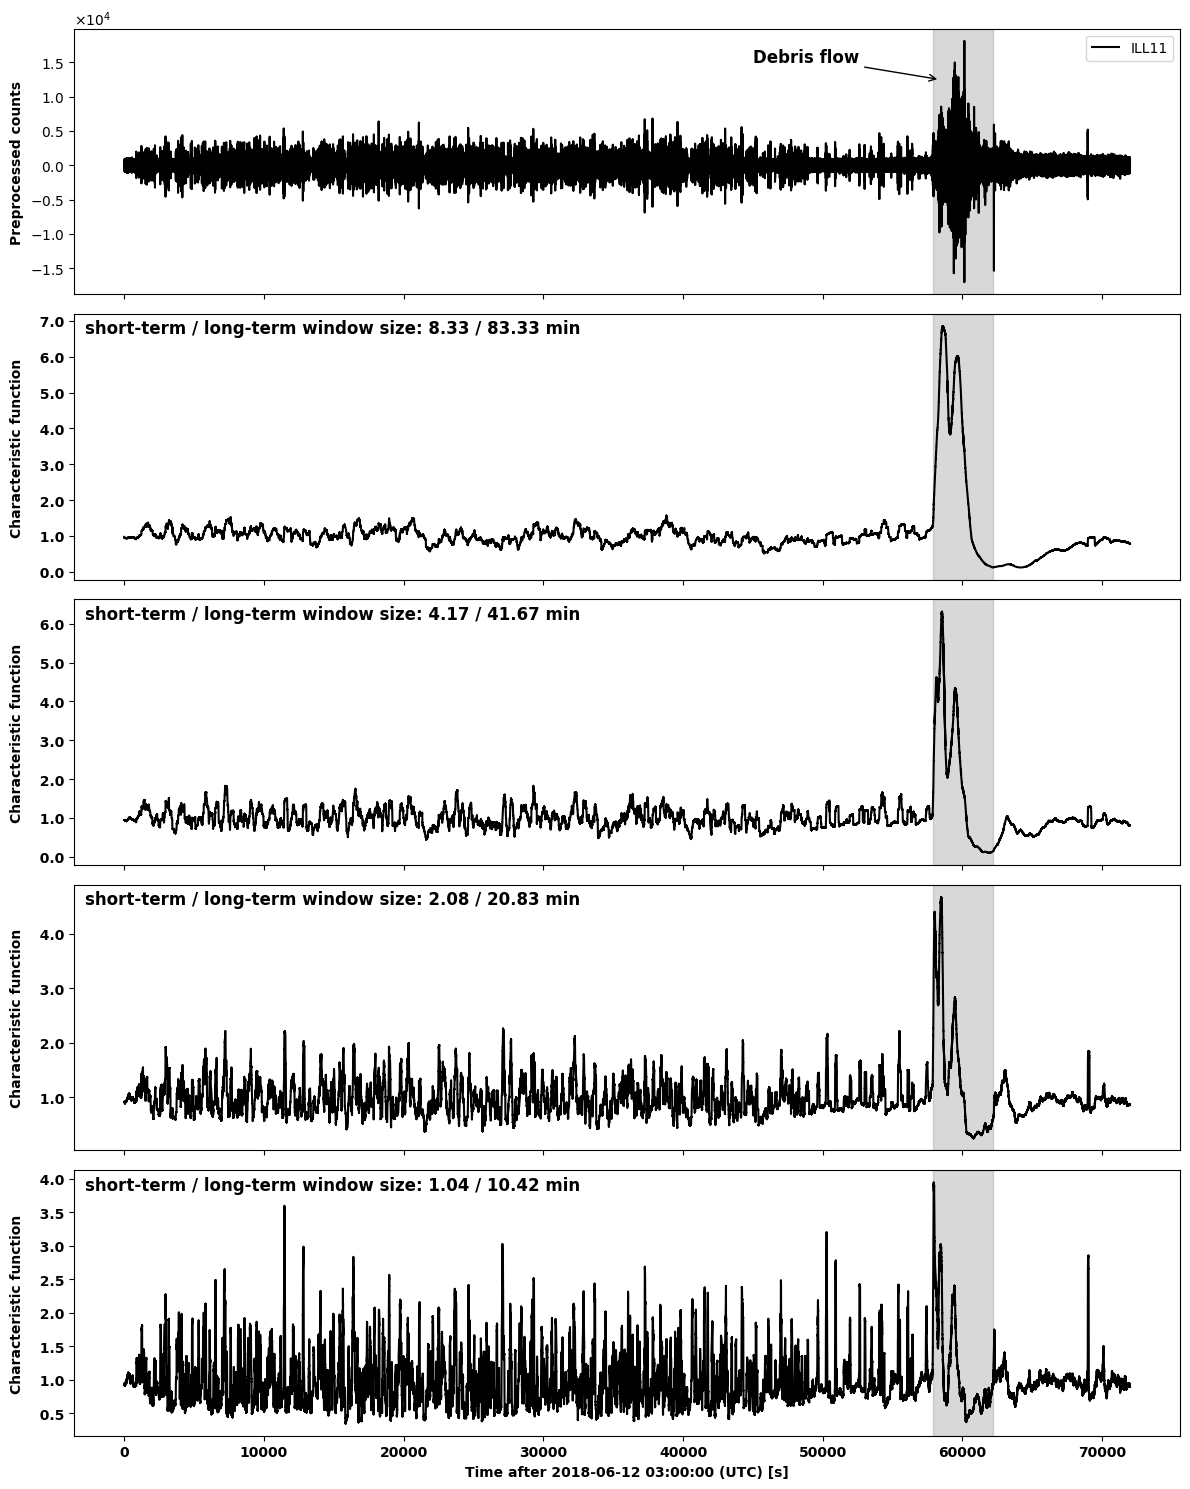

In [201]:
sw, lw = 50000, 500000
fig, axs = plt.subplots(5, 1, figsize=(12, 15), sharex=True)
axs = axs.flatten()

for ax in axs:
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%5.1f"))

tr = st.copy().trim(t0, t1)[0]
npts = tr.stats.npts
sampling_rate = tr.stats.sampling_rate
dt = 1 / sampling_rate
start_offset = tr.stats.starttime - t0
t = np.arange(0, npts) * dt + start_offset
axs[0].plot(t, tr.data, color="black", label="ILL11")
axs[0].set_ylabel("Preprocessed counts", fontweight="bold")

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((4, 4))  # Force 10^4 notation
axs[0].yaxis.set_major_formatter(formatter)
axs[0].ticklabel_format(style="sci", axis="y", scilimits=(4, 4))
axs[0].legend()
axs[0].axvspan(flow_start, flow_stop, color="gray", alpha=0.3)

axs[0].annotate(
    "Debris flow",
    xy=(flow_start + 500, 12500),
    xytext=(45000, 15000),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
)

for h in range(1, 5):
    tr = st.copy()[0]
    tr = create_slta_trace(tr, sw, lw, station="ILL11")

    tr = tr.trim(t0, t1)
    npts = tr.stats.npts
    sampling_rate = tr.stats.sampling_rate
    dt = 1 / sampling_rate
    start_offset = tr.stats.starttime - t0
    t = np.arange(0, npts) * dt + start_offset
    axs[h].plot(t, tr.data, color="black")
    axs[h].set_ylabel("Characteristic function", fontweight="bold")

    if h < len(axs) - 1:
        axs[h].tick_params(labelbottom=False)

    axs[h].text(
        0.01,
        0.98,
        f"short-term / long-term window size: {sw / 100 / 60:.2f} / {lw / 100 / 60:.2f} min",
        transform=axs[h].transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        ha="left",
    )

    axs[h].axvspan(flow_start, flow_stop, color="gray", alpha=0.3)

    for label in axs[h].get_yticklabels():
        label.set_fontweight("bold")

    sw = sw / 2
    lw = lw / 2


axs[h].set_xlabel(
    f"Time after {t0.strftime('%Y-%m-%d %H:%M:%S')} (UTC) [s]", fontweight="bold"
)

for label in axs[h].get_xticklabels():
    label.set_fontweight("bold")


plt.tight_layout()
plt.savefig("../plots/fig08.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

In [403]:
# ILL11 2020-08-30
sw = 50000
lw = 500000

ill11_paths = find_paths("XP", "ILL11", "HHZ.D", start=2018, stop=2022)
example_path = find_date_in_strings(ill11_paths, "2020-08-30")[0]

st = obspy.read(example_path)
st_prev = obspy.read(find_date_in_strings(ill11_paths, "2020-08-29")[0])
preproc_stream(st)
preproc_stream(st_prev)

t0 = obspy.UTCDateTime("2020-08-30T05:00:00.000000Z")
t1 = obspy.UTCDateTime("2020-08-30T15:00:00.000000Z")

t0_gt1 = obspy.UTCDateTime("2020-08-30T05:44:00.000000Z")
t1_gt1 = obspy.UTCDateTime("2020-08-30T07:23:00.000000Z")

t0_gt2 = obspy.UTCDateTime("2020-08-30T08:00:00.000000Z")
t1_gt2 = obspy.UTCDateTime("2020-08-30T08:52:00.000000Z")

flow_start1 = t0_gt1 - t0
flow_stop1 = t1_gt1 - t0

flow_start2 = t0_gt2 - t0
flow_stop2 = t1_gt2 - t0

scores_df = pd.read_csv(f"../output/XP/if/scores/ILL11.csv", index_col=0)
scores_df = scores_df.iloc[
    : np.max(np.where(["2020" in i for i in scores_df["start"]])[0]), :
]
scores_df["start"] = [obspy.UTCDateTime(i) for i in scores_df["start"]]
scores_df["stop"] = [obspy.UTCDateTime(i) for i in scores_df["stop"]]
ill11_if_st = create_if_stream(scores_df, station="ILL11", sr=0.02, network="XP")

sta_lta_tr = st[-1].copy()
sta_lta_tr = create_slta_trace(sta_lta_tr, sw, lw)

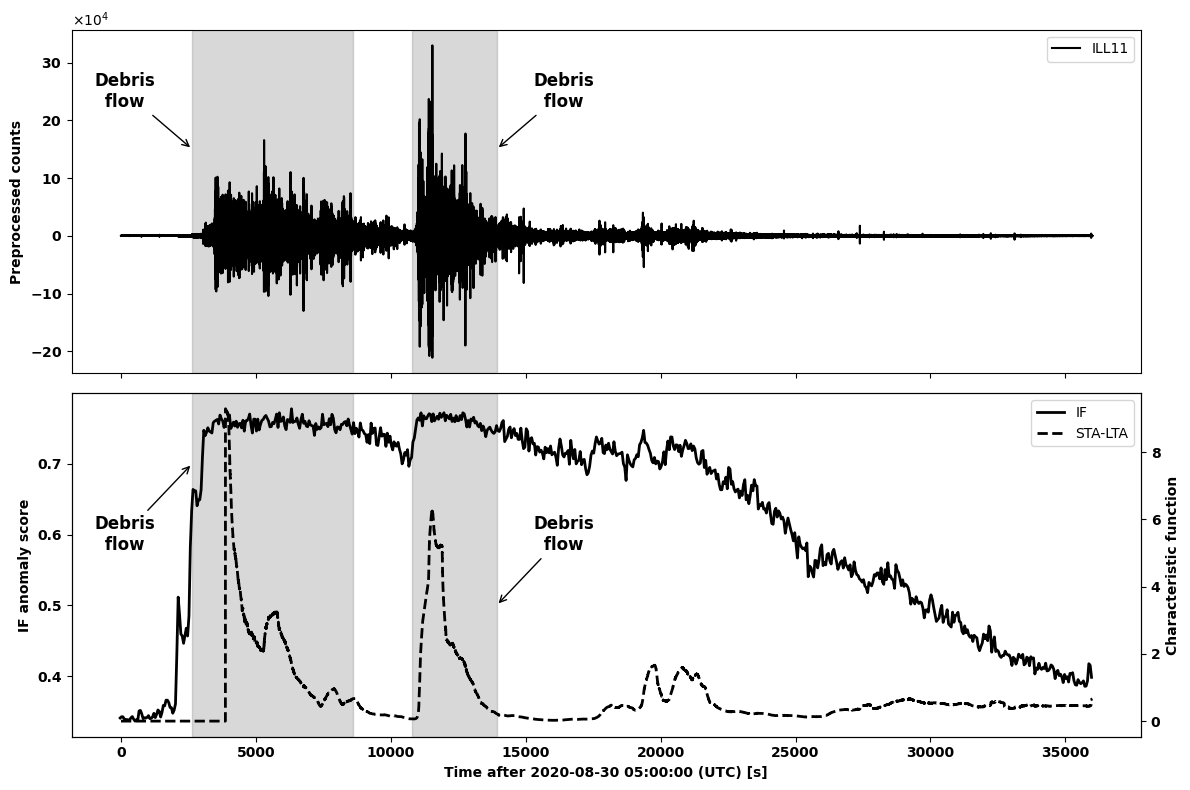

In [404]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

tr = st.copy().trim(t0, t1)[0]
npts = tr.stats.npts
sampling_rate = tr.stats.sampling_rate
dt = 1 / sampling_rate
start_offset = tr.stats.starttime - t0
t = np.arange(0, npts) * dt + start_offset
axs[0].plot(t, tr.data, color="black", label="ILL11")
axs[0].set_ylabel("Preprocessed counts", fontweight="bold")

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((4, 4))  # Force 10^4 notation
axs[0].yaxis.set_major_formatter(formatter)
axs[0].ticklabel_format(style="sci", axis="y", scilimits=(4, 4))
axs[0].legend()
axs[0].axvspan(flow_start1, flow_stop1, color="gray", alpha=0.3)
axs[0].axvspan(flow_start2, flow_stop2, color="gray", alpha=0.3)

for label in axs[0].get_yticklabels():
    label.set_fontweight("bold")

axs[0].annotate(
    "Debris\n flow ",
    xy=(flow_stop2, 150000),
    xytext=(flow_stop2 + 2500, 250000),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="center",
)

axs[0].annotate(
    "Debris\n flow ",
    xy=(flow_start1, 150000),
    xytext=(flow_start1 - 2500, 250000),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="center",
)


if_tr = ill11_if_st.copy().trim(t0, t1)[0]
npts = if_tr.stats.npts
sampling_rate = if_tr.stats.sampling_rate
dt = 1 / sampling_rate
start_offset = if_tr.stats.starttime - t0
t = np.arange(0, npts) * dt + start_offset
axs[1].plot(t, if_tr.data, color="black", label="IF", linestyle="solid", linewidth=2)
axs[1].set_ylabel("IF anomaly score", fontweight="bold")

slta_tr = sta_lta_tr.copy().trim(t0, t1)
npts = slta_tr.stats.npts
sampling_rate = slta_tr.stats.sampling_rate
dt = 1 / sampling_rate
start_offset = slta_tr.stats.starttime - t0
t = np.arange(0, npts) * dt + start_offset

for label in axs[1].get_yticklabels():
    label.set_fontweight("bold")

for label in axs[1].get_xticklabels():
    label.set_fontweight("bold")

ax2 = axs[1].twinx()
ax2.plot(
    t, slta_tr.data, color="black", label="STA-LTA", linestyle="dashed", linewidth=2
)
ax2.set_ylabel("Characteristic function", fontweight="bold")

for label in ax2.get_yticklabels():
    label.set_fontweight("bold")

axs[1].axvspan(flow_start1, flow_stop1, color="gray", alpha=0.3)
axs[1].axvspan(flow_start2, flow_stop2, color="gray", alpha=0.3)

axs[1].set_xlabel(
    f"Time after {t0.strftime('%Y-%m-%d %H:%M:%S')} (UTC) [s]", fontweight="bold"
)

lines1, labels1 = axs[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

axs[1].legend(lines1 + lines2, labels1 + labels2, loc="upper right")

axs[1].annotate(
    "Debris\n flow ",
    xy=(flow_stop2, 0.5),
    xytext=(flow_stop2 + 2500, 0.6),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="center",
)

axs[1].annotate(
    "Debris\n flow ",
    xy=(flow_start1, 0.7),
    xytext=(flow_start1 - 2500, 0.6),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="center",
)

plt.tight_layout()
plt.savefig("../plots/fig09.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

In [405]:
# ILL12 2020-06-08
sw = 200000
lw = 4000000

ill12_paths = find_paths("XP", "ILL12", "EHZ.D", start=2018, stop=2022)
example_path = find_date_in_strings(ill12_paths, "2020-06-08")[0]

st = obspy.read(example_path)
st_prev = obspy.read(find_date_in_strings(ill12_paths, "2020-06-07")[0])
preproc_stream(st)
preproc_stream(st_prev)

t0 = obspy.UTCDateTime("2020-06-08T10:00:00.000000Z")
t1 = obspy.UTCDateTime("2020-06-08T23:00:00.000000Z")

t0_gt1 = obspy.UTCDateTime("2020-06-08T14:05:00.000000Z")
t1_gt1 = obspy.UTCDateTime("2020-06-08T14:35:00.000000Z	")

t0_gt2 = obspy.UTCDateTime("2020-06-08T16:53:00.000000Z")
t1_gt2 = obspy.UTCDateTime("2020-06-08T17:40:00.000000Z	")

flow_start1 = t0_gt1 - t0
flow_stop1 = t1_gt1 - t0

flow_start2 = t0_gt2 - t0
flow_stop2 = t1_gt2 - t0

scores_df = pd.read_csv(f"../output/XP/if/scores/ILL12.csv", index_col=0)
scores_df = scores_df.iloc[
    : np.max(np.where(["2020" in i for i in scores_df["start"]])[0]), :
]
scores_df["start"] = [obspy.UTCDateTime(i) for i in scores_df["start"]]
scores_df["stop"] = [obspy.UTCDateTime(i) for i in scores_df["stop"]]
ill12_if_st = create_if_stream(scores_df, station="ILL12", sr=0.02, network="XP")

sta_lta_tr = obspy.Trace()
sta_lta_tr.data = np.append(st_prev[0].data, st[0].data)
sta_lta_tr.stats.sampling_rate = 100
sta_lta_tr.stats.starttime = st_prev[0].stats.starttime
sta_lta_tr = create_slta_trace(sta_lta_tr, sw, lw)

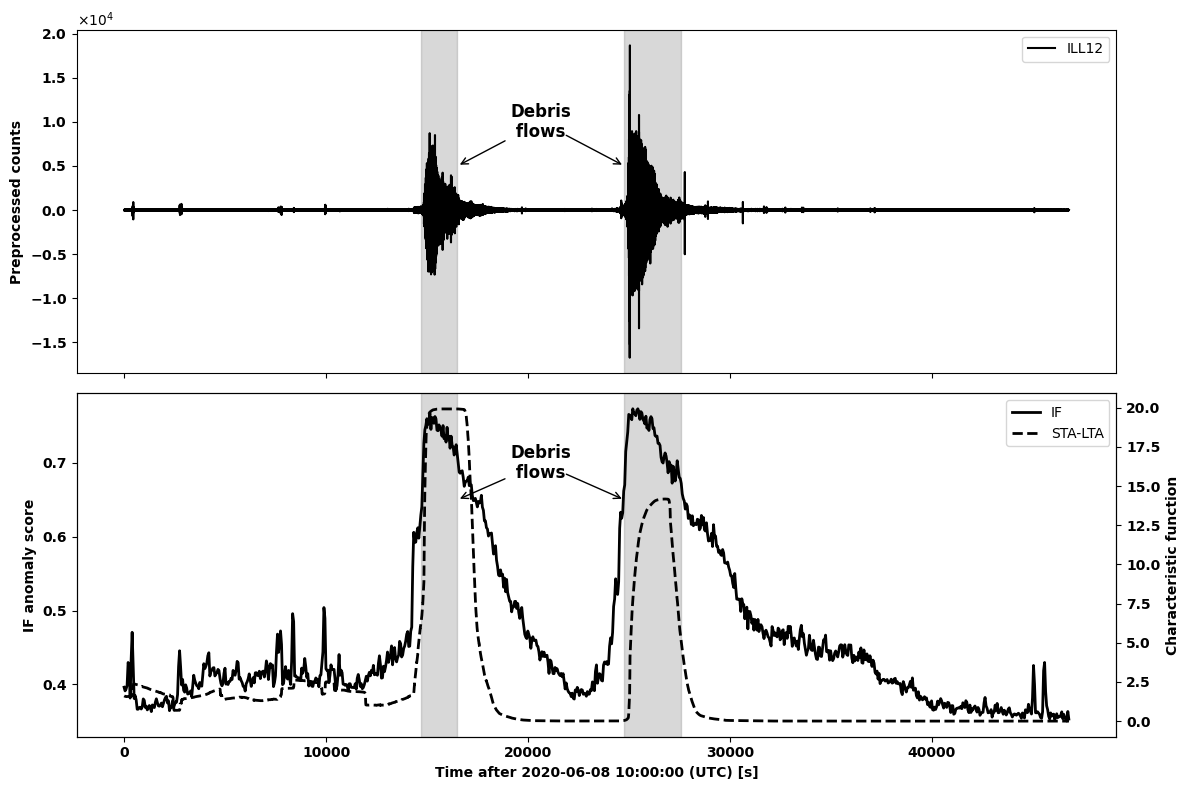

In [406]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

tr = st.copy().trim(t0, t1)[0]
npts = tr.stats.npts
sampling_rate = tr.stats.sampling_rate
dt = 1 / sampling_rate
start_offset = tr.stats.starttime - t0
t = np.arange(0, npts) * dt + start_offset
axs[0].plot(t, tr.data, color="black", label="ILL12")
axs[0].set_ylabel("Preprocessed counts", fontweight="bold")

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((4, 4))  # Force 10^4 notation
axs[0].yaxis.set_major_formatter(formatter)
axs[0].ticklabel_format(style="sci", axis="y", scilimits=(4, 4))
axs[0].legend()
axs[0].axvspan(flow_start1, flow_stop1, color="gray", alpha=0.3)
axs[0].axvspan(flow_start2, flow_stop2, color="gray", alpha=0.3)

for label in axs[0].get_yticklabels():
    label.set_fontweight("bold")

axs[0].annotate(
    "Debris\n flows ",
    xy=(flow_stop1, 5000),
    xytext=(20640, 10000),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="center",
)

axs[0].annotate(
    "      \n       ",
    xy=(flow_start2, 5000),
    xytext=(20640, 10000),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="center",
)

if_tr = ill12_if_st.copy().trim(t0, t1)[0]
npts = if_tr.stats.npts
sampling_rate = if_tr.stats.sampling_rate
dt = 1 / sampling_rate
start_offset = if_tr.stats.starttime - t0
t = np.arange(0, npts) * dt + start_offset
axs[1].plot(t, if_tr.data, color="black", label="IF", linestyle="solid", linewidth=2)
axs[1].set_ylabel("IF anomaly score", fontweight="bold")

slta_tr = sta_lta_tr.copy().trim(t0, t1)
npts = slta_tr.stats.npts
sampling_rate = slta_tr.stats.sampling_rate
dt = 1 / sampling_rate
start_offset = slta_tr.stats.starttime - t0
t = np.arange(0, npts) * dt + start_offset

for label in axs[1].get_yticklabels():
    label.set_fontweight("bold")

for label in axs[1].get_xticklabels():
    label.set_fontweight("bold")

ax2 = axs[1].twinx()
ax2.plot(
    t, slta_tr.data, color="black", label="STA-LTA", linestyle="dashed", linewidth=2
)
ax2.set_ylabel("Characteristic function", fontweight="bold")

for label in ax2.get_yticklabels():
    label.set_fontweight("bold")

axs[1].axvspan(flow_start1, flow_stop1, color="gray", alpha=0.3)
axs[1].axvspan(flow_start2, flow_stop2, color="gray", alpha=0.3)

axs[1].set_xlabel(
    f"Time after {t0.strftime('%Y-%m-%d %H:%M:%S')} (UTC) [s]", fontweight="bold"
)

lines1, labels1 = axs[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

axs[1].legend(lines1 + lines2, labels1 + labels2, loc="upper right")

axs[1].annotate(
    "Debris\n flows ",
    xy=(flow_stop1, 0.65),
    xytext=(20640, 0.70),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="center",
)

axs[1].annotate(
    "      \n       ",
    xy=(flow_start2, 0.65),
    xytext=(20640, 0.70),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="center",
)

plt.tight_layout()
plt.savefig("../plots/fig10.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

In [407]:
# ILL18 2021-07-31
sw = 50000
lw = 4000000

ill18_paths = find_paths("XP", "ILL18", "EHZ.D", start=2018, stop=2022)
example_path = find_date_in_strings(ill18_paths, "2021-07-31")[0]

st = obspy.read(example_path)
st_prev = obspy.read(find_date_in_strings(ill18_paths, "2021-07-30")[0])
preproc_stream(st)
preproc_stream(st_prev)

t0 = obspy.UTCDateTime("2021-07-31T18:00:00.000000Z")
t1 = obspy.UTCDateTime("2021-07-31T23:59:59.000000Z")

t0_gt1 = obspy.UTCDateTime("2021-07-31T21:08:09.000000Z")
t1_gt1 = obspy.UTCDateTime("2021-07-31T22:21:59.000000Z")

t0_gt2 = obspy.UTCDateTime("2021-07-31T23:04:34.000000Z")
t1_gt2 = obspy.UTCDateTime("2021-07-31T23:39:34.000000Z")

flow_start1 = t0_gt1 - t0
flow_stop1 = t1_gt1 - t0

flow_start2 = t0_gt2 - t0
flow_stop2 = t1_gt2 - t0

scores_df = pd.read_csv(f"../output/XP/if/scores/ILL18.csv", index_col=0)
scores_df = scores_df.iloc[
    : np.max(np.where(["2021" in i for i in scores_df["start"]])[0]), :
]
scores_df["start"] = [obspy.UTCDateTime(i) for i in scores_df["start"]]
scores_df["stop"] = [obspy.UTCDateTime(i) for i in scores_df["stop"]]
ill18_if_st = create_if_stream(scores_df, station="ILL18", sr=0.02, network="XP")

sta_lta_tr = obspy.Trace()
sta_lta_tr.data = np.append(st_prev[0].data, st[0].data)
sta_lta_tr.stats.sampling_rate = 100
sta_lta_tr.stats.starttime = st_prev[0].stats.starttime
sta_lta_tr = create_slta_trace(sta_lta_tr, sw, lw)

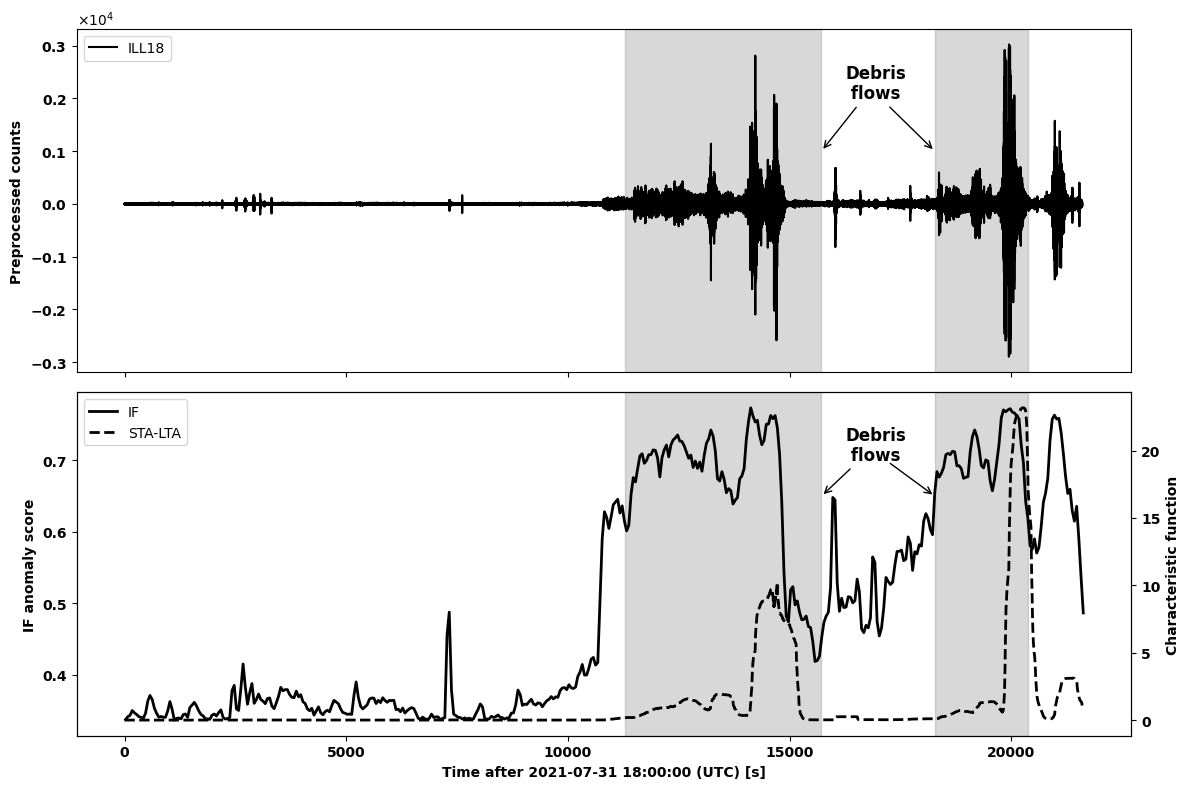

In [409]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

tr = st.copy().trim(t0, t1)[0]
npts = tr.stats.npts
sampling_rate = tr.stats.sampling_rate
dt = 1 / sampling_rate
start_offset = tr.stats.starttime - t0
t = np.arange(0, npts) * dt + start_offset
axs[0].plot(t, tr.data, color="black", label="ILL18")
axs[0].set_ylabel("Preprocessed counts", fontweight="bold")

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((4, 4))  # Force 10^4 notation
axs[0].yaxis.set_major_formatter(formatter)
axs[0].ticklabel_format(style="sci", axis="y", scilimits=(4, 4))
axs[0].legend(loc="upper left")
axs[0].axvspan(flow_start1, flow_stop1, color="gray", alpha=0.3)
axs[0].axvspan(flow_start2, flow_stop2, color="gray", alpha=0.3)

for label in axs[0].get_yticklabels():
    label.set_fontweight("bold")

axs[0].annotate(
    "Debris\n flows ",
    xy=(flow_stop1, 1000),
    xytext=(16250, 2000),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
)

axs[0].annotate(
    "      \n       ",
    xy=(flow_start2, 1000),
    xytext=(16250, 2000),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
)

if_tr = ill18_if_st.copy().trim(t0, t1)[0]
npts = if_tr.stats.npts
sampling_rate = if_tr.stats.sampling_rate
dt = 1 / sampling_rate
start_offset = if_tr.stats.starttime - t0
t = np.arange(0, npts) * dt + start_offset
axs[1].plot(t, if_tr.data, color="black", label="IF", linestyle="solid", linewidth=2)
axs[1].set_ylabel("IF anomaly score", fontweight="bold")

slta_tr = sta_lta_tr.copy().trim(t0, t1)
npts = slta_tr.stats.npts
sampling_rate = slta_tr.stats.sampling_rate
dt = 1 / sampling_rate
start_offset = slta_tr.stats.starttime - t0
t = np.arange(0, npts) * dt + start_offset

for label in axs[1].get_yticklabels():
    label.set_fontweight("bold")

for label in axs[1].get_xticklabels():
    label.set_fontweight("bold")

ax2 = axs[1].twinx()
ax2.plot(
    t, slta_tr.data, color="black", label="STA-LTA", linestyle="dashed", linewidth=2
)
ax2.set_ylabel("Characteristic function", fontweight="bold")

for label in ax2.get_yticklabels():
    label.set_fontweight("bold")

axs[1].axvspan(flow_start1, flow_stop1, color="gray", alpha=0.3)
axs[1].axvspan(flow_start2, flow_stop2, color="gray", alpha=0.3)

axs[1].set_xlabel(
    f"Time after {t0.strftime('%Y-%m-%d %H:%M:%S')} (UTC) [s]", fontweight="bold"
)

lines1, labels1 = axs[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

axs[1].legend(lines1 + lines2, labels1 + labels2, loc="upper left")

axs[1].annotate(
    "Debris\n flows ",
    xy=(flow_stop1, 0.65),
    xytext=(16250, 0.7),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
)

axs[1].annotate(
    "      \n       ",
    xy=(flow_start2, 0.65),
    xytext=(16250, 0.7),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    fontweight="bold",
)

plt.tight_layout()
plt.savefig("../plots/fig11.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()